# Data Description

In [1]:
import pandas as pd 
from pandas.plotting import parallel_coordinates
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy import stats
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
  
data = pd.read_csv("diabetes1.csv")

data.head(5)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35,0.0,33.6,0.627,50.0,1
1,1,85.0,66.0,29,0.0,26.6,0.351,31.0,0
2,8,183.0,64.0,0,0.0,23.3,0.672,32.0,1
3,1,89.0,66.0,23,94.0,28.1,0.167,21.0,0
4,0,137.0,40.0,35,168.0,43.1,2.288,33.0,1


## Indept Data Description

In [2]:
# Data Shape
data.shape

(771, 9)

In [3]:
# Data Description
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,771.000000,770.000000,770.000000,771.000000,768.000000,771.000000,771.000000,770.000000,771.000000
mean,3.818418,121.179221,69.748052,20.438392,80.029948,35.440986,0.471000,33.122078,0.347601
std,3.355666,32.046319,27.045623,15.893061,116.332876,98.206467,0.330802,11.693336,0.476517
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.100000,0.243500,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,24.000000,32.000000,0.368000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,126.000000,36.500000,0.628000,40.000000,1.000000
max,17.000000,199.000000,472.000000,99.000000,846.000000,2750.000000,2.420000,81.000000,1.000000


In [4]:
# Info on Abnormal Values
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,771.0,3.818418,3.355666,0.000,1.0000,3.000,6.000,17.00
Glucose,770.0,121.179221,32.046319,0.000,99.0000,117.000,141.000,199.00
BloodPressure,770.0,69.748052,27.045623,0.000,62.0000,72.000,80.000,472.00
SkinThickness,771.0,20.438392,15.893061,0.000,0.0000,23.000,32.000,99.00
Insulin,768.0,80.029948,116.332876,0.000,0.0000,24.000,126.000,846.00
BMI,771.0,35.440986,98.206467,0.000,27.1000,32.000,36.500,2750.00
DiabetesPedigreeFunction,771.0,0.471000,0.330802,0.078,0.2435,0.368,0.628,2.42
Age,770.0,33.122078,11.693336,21.000,24.0000,29.000,40.000,81.00
Outcome,771.0,0.347601,0.476517,0.000,0.0000,0.000,1.000,1.00


In [5]:
# Info on the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 771 entries, 0 to 770
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               771 non-null    int64  
 1   Glucose                   770 non-null    float64
 2   BloodPressure             770 non-null    float64
 3   SkinThickness             771 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       771 non-null    float64
 6   DiabetesPedigreeFunction  771 non-null    float64
 7   Age                       770 non-null    float64
 8   Outcome                   771 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.3 KB


In [6]:
# Check for duplicates
data.duplicated().sum()

np.int64(5)

In [7]:
# Note:
# - Blood Pressure > 0
# - BMI > 0

# Check for null values
data.isnull().sum()

Pregnancies                 0
Glucose                     1
BloodPressure               1
SkinThickness               0
Insulin                     3
BMI                         0
DiabetesPedigreeFunction    0
Age                         1
Outcome                     0
dtype: int64

In [8]:
# Check for 0 values
columns_to_check = ['Glucose', 'BloodPressure', 'Insulin', 'SkinThickness', 'BMI', 'Age']
zero_counts = data[columns_to_check].apply(lambda col: (col == 0).sum())
print(zero_counts)


Glucose            5
BloodPressure     37
Insulin          376
SkinThickness    228
BMI               11
Age                0
dtype: int64


In [9]:
data.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.122444,0.149337,-0.084709,-0.089617,-0.018023,-0.035889,0.544475,0.227137
Glucose,0.122444,1.000000,0.088065,0.053264,0.340357,0.045141,0.146088,0.252427,0.452962
BloodPressure,0.149337,0.088065,1.000000,0.188303,0.037676,-0.077158,0.017106,0.197087,0.053918
SkinThickness,-0.084709,0.053264,0.188303,1.000000,0.427375,-0.014535,0.185054,-0.117578,0.071253
Insulin,-0.089617,0.340357,0.037676,0.427375,1.000000,-0.009544,0.189477,-0.054184,0.117818
BMI,-0.018023,0.045141,-0.077158,-0.014535,-0.009544,1.000000,-0.013727,-0.012476,0.072746
DiabetesPedigreeFunction,-0.035889,0.146088,0.017106,0.185054,0.189477,-0.013727,1.000000,0.038149,0.171227
Age,0.544475,0.252427,0.197087,-0.117578,-0.054184,-0.012476,0.038149,1.000000,0.241777
Outcome,0.227137,0.452962,0.053918,0.071253,0.117818,0.072746,0.171227,0.241777,1.000000


# Data Visualisation

## Univariate Analysis

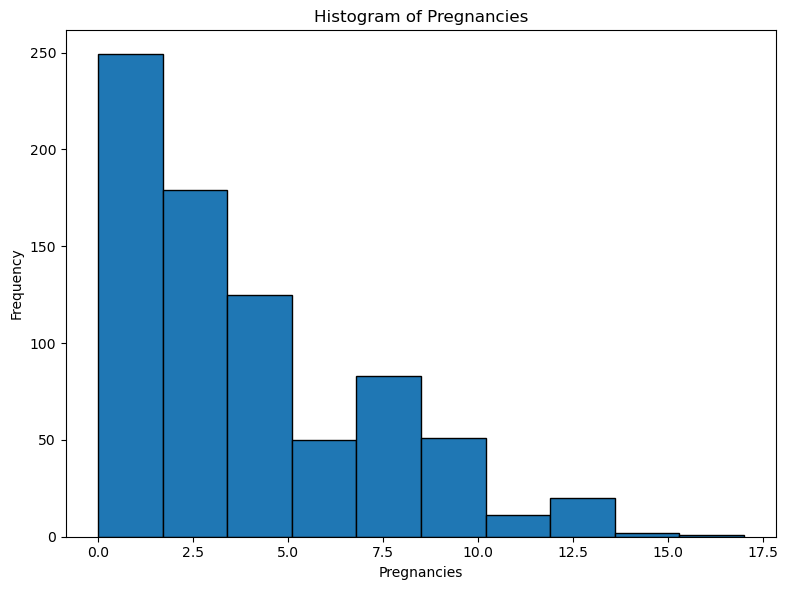

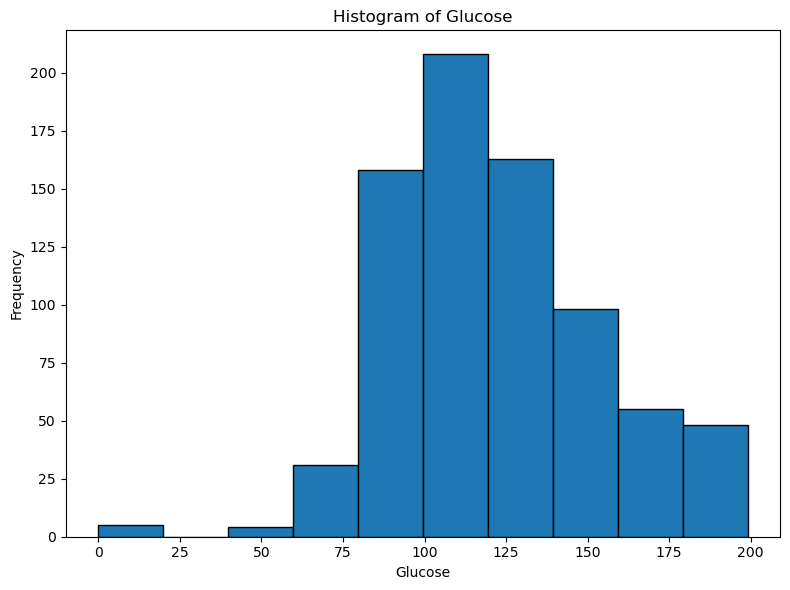

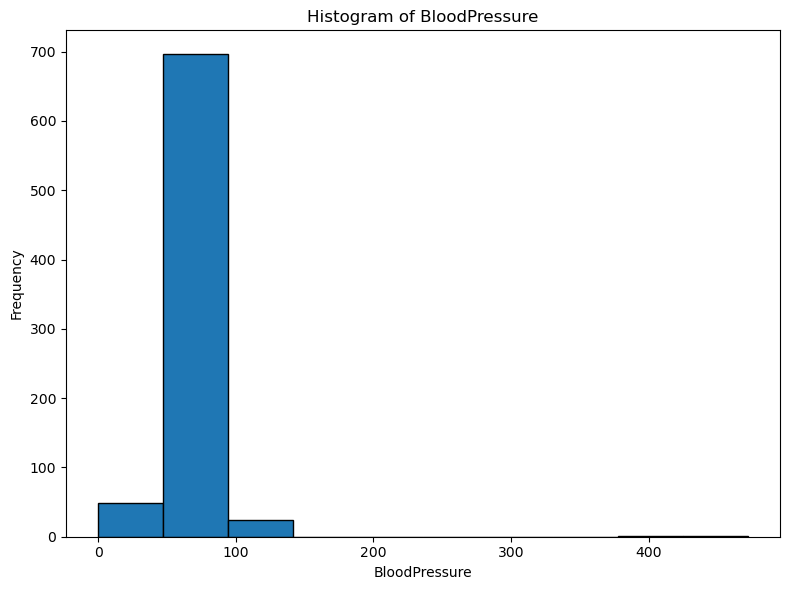

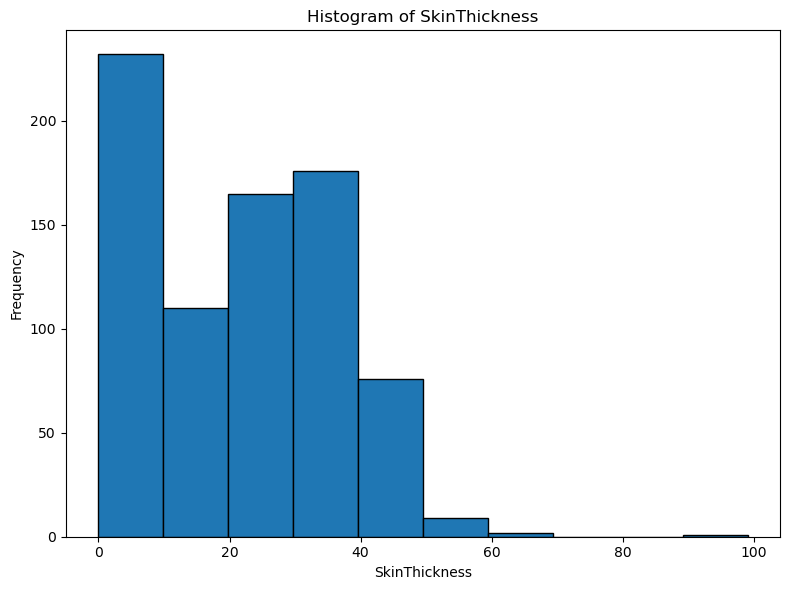

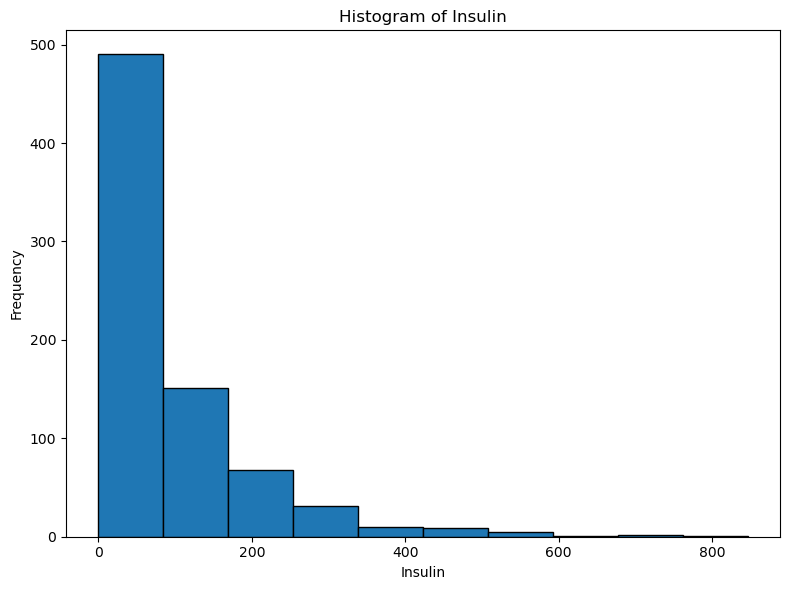

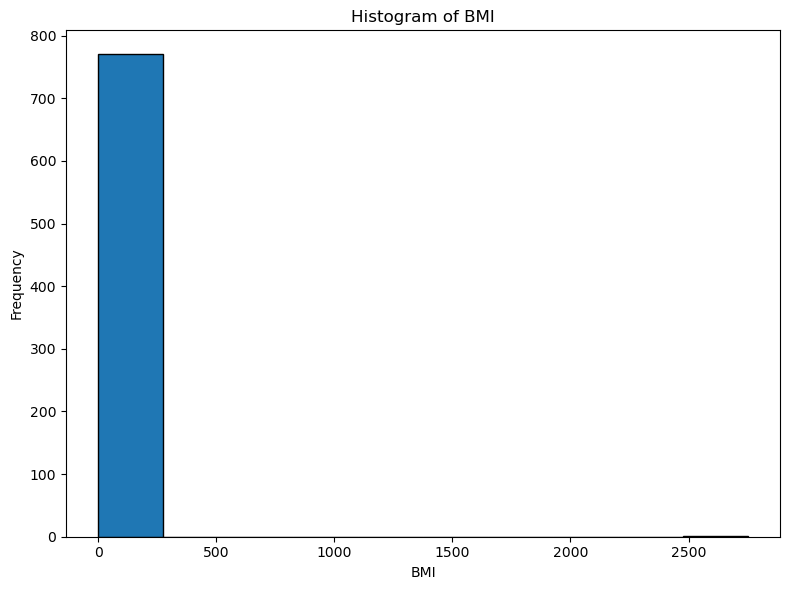

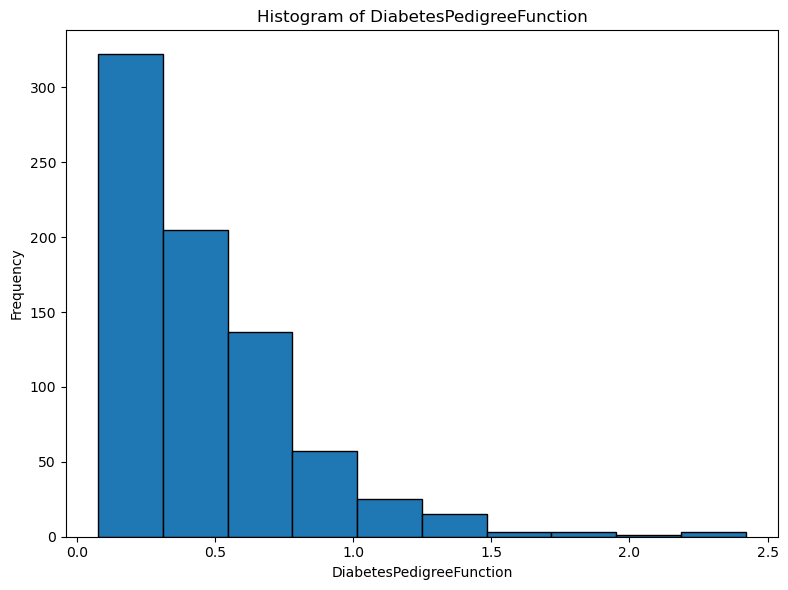

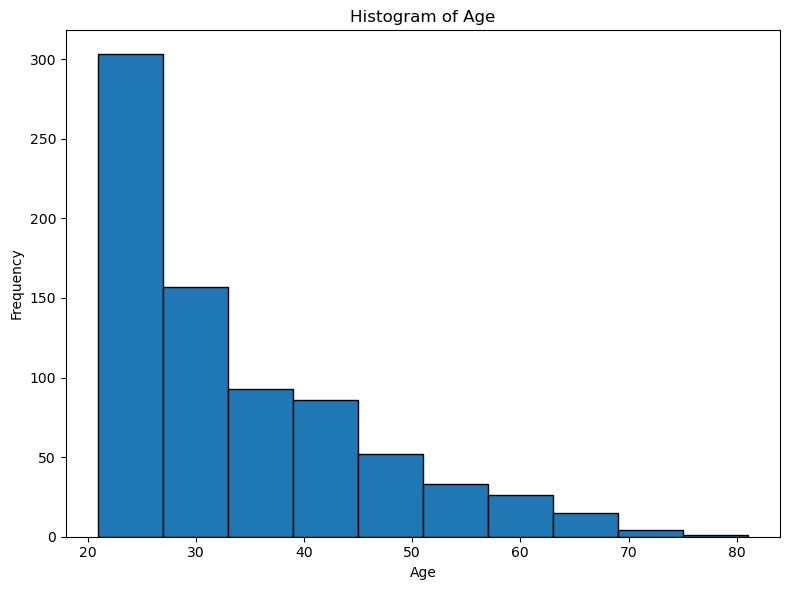

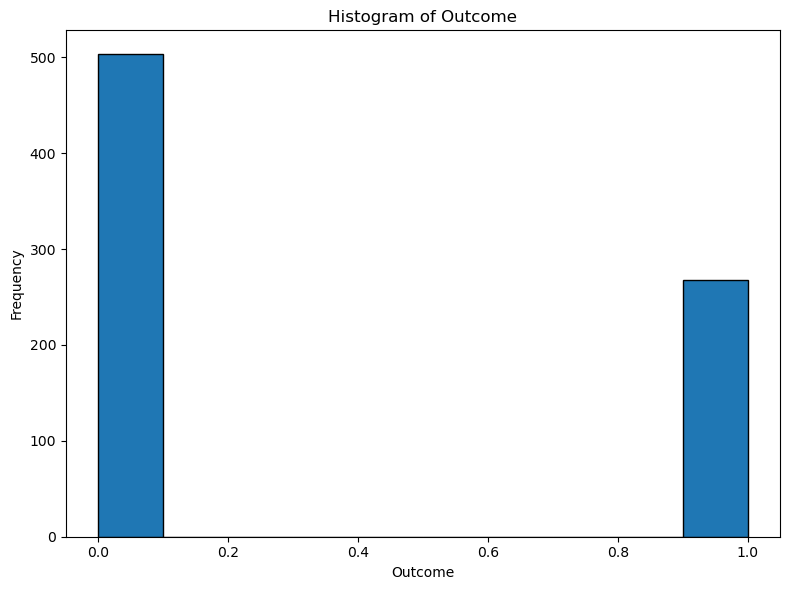

In [10]:
# Histogram
for column in data.columns:
    plt.figure(figsize=(8, 6))
    data[column].hist(edgecolor='black')
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(False)
    plt.tight_layout()
    plt.show()

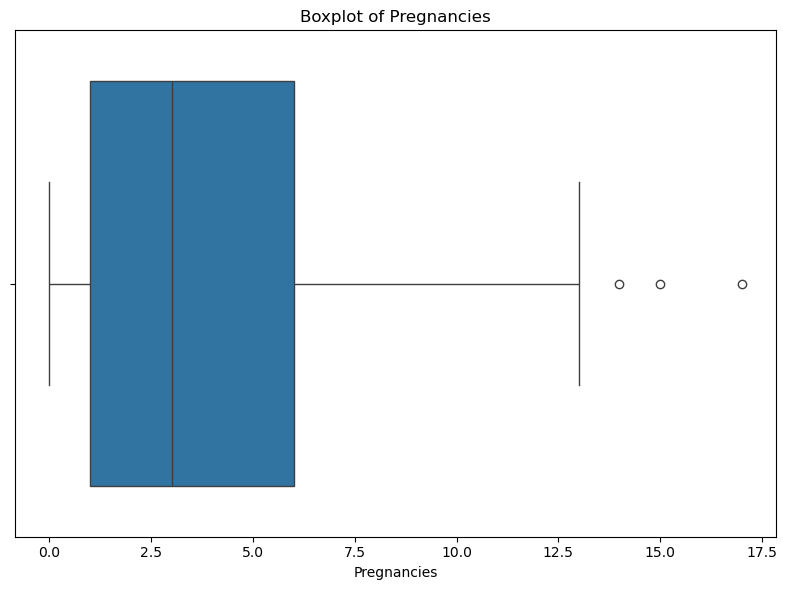

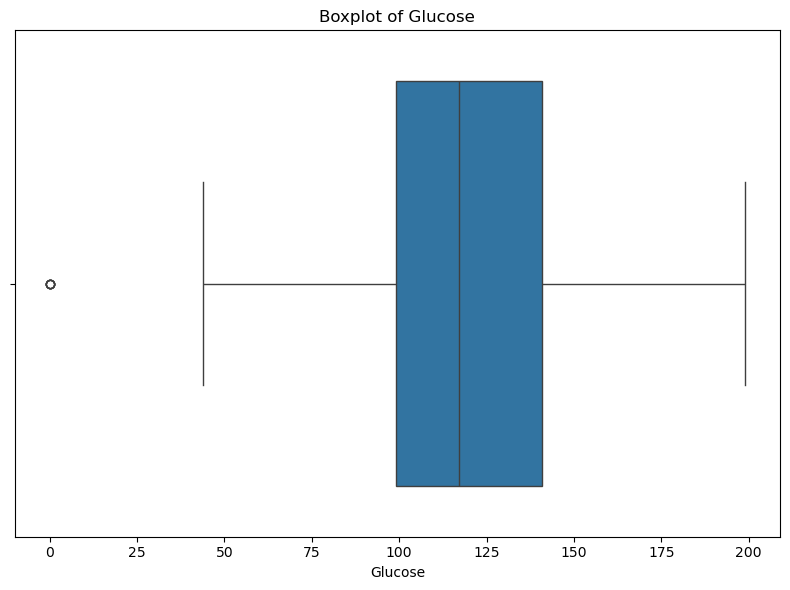

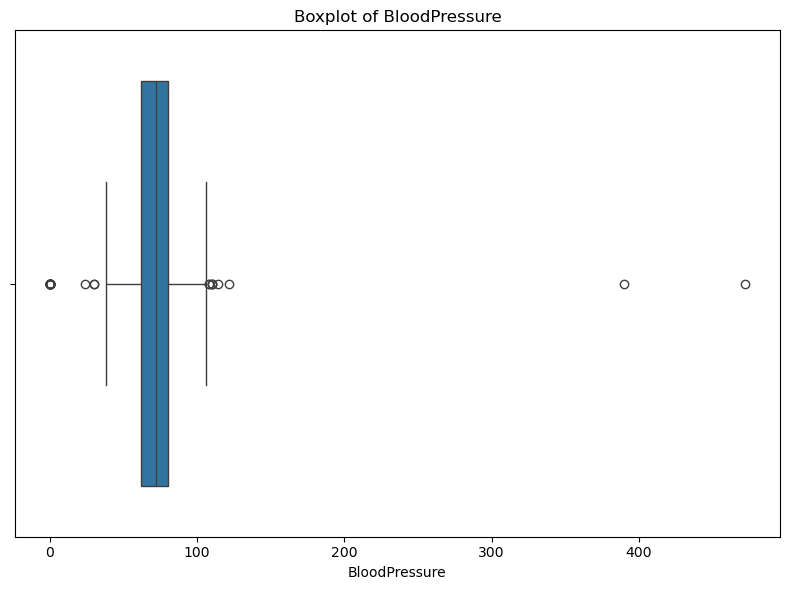

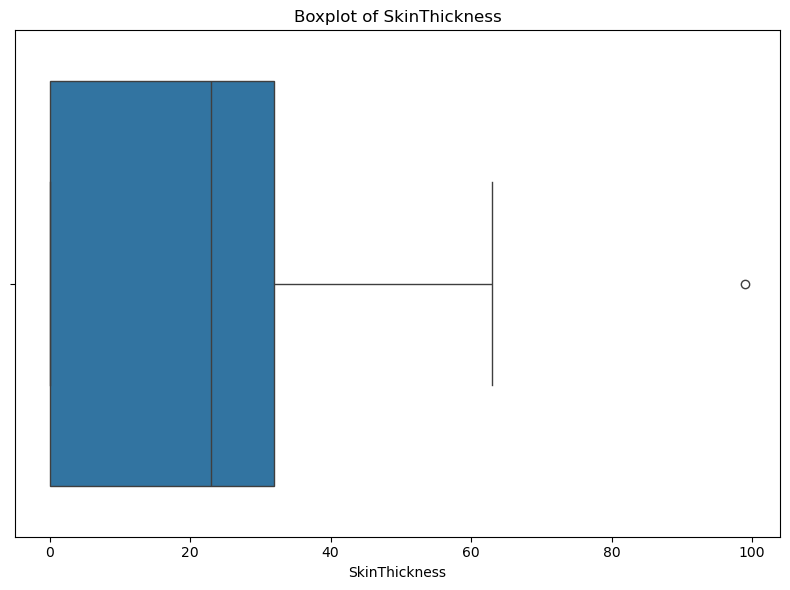

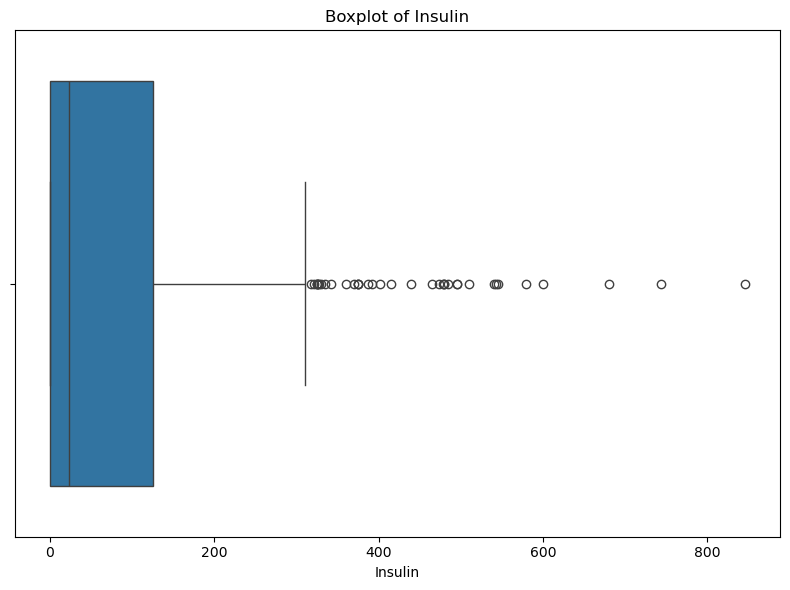

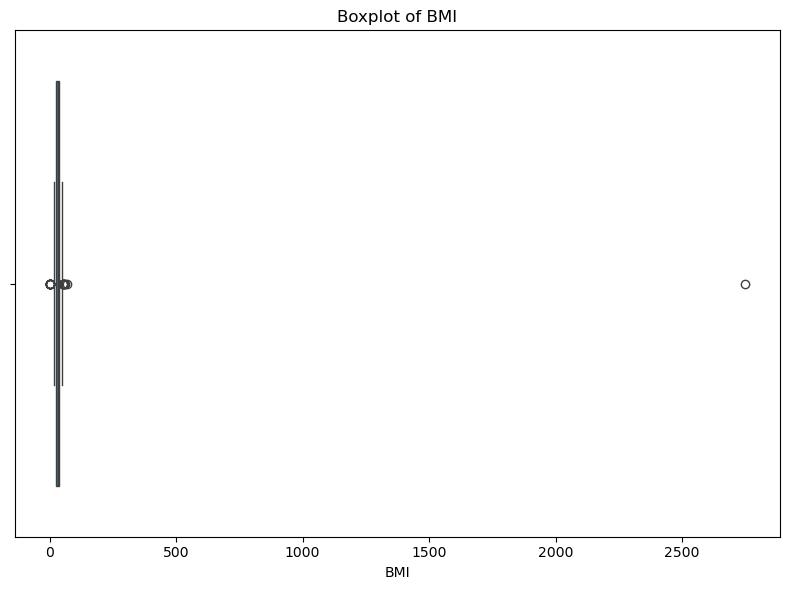

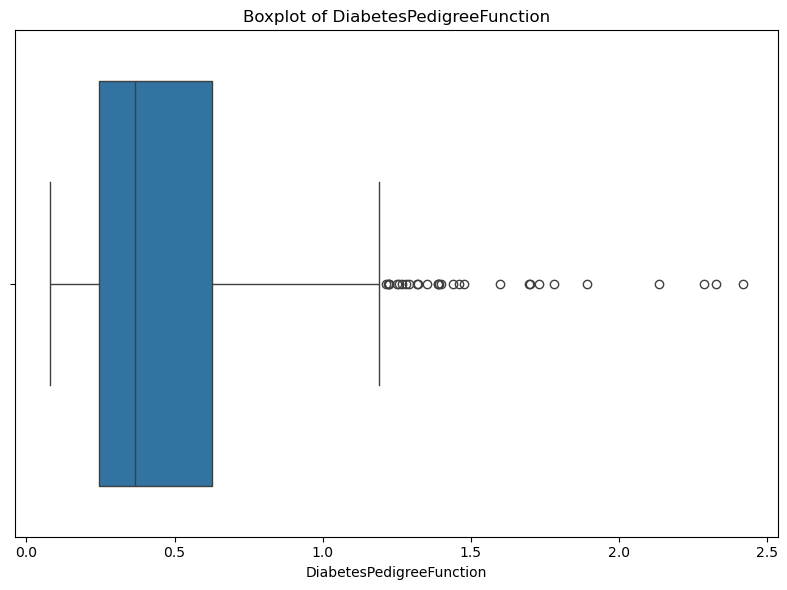

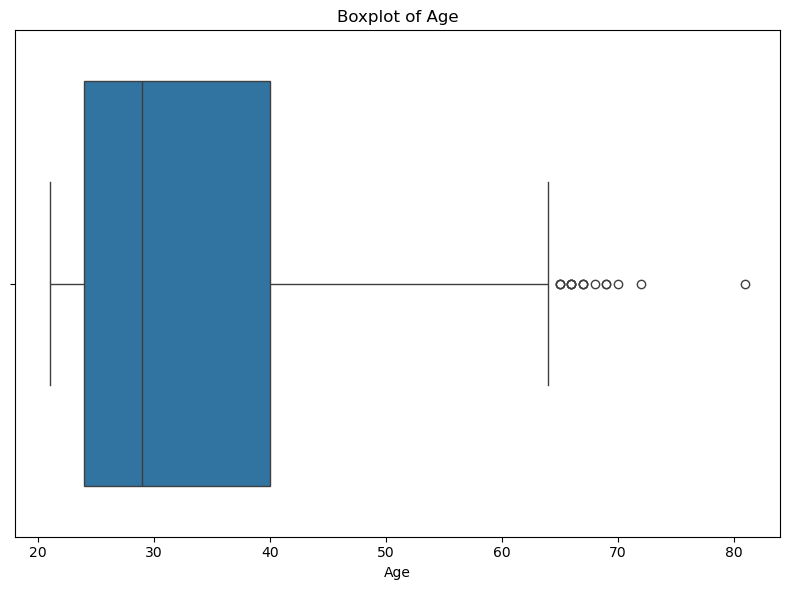

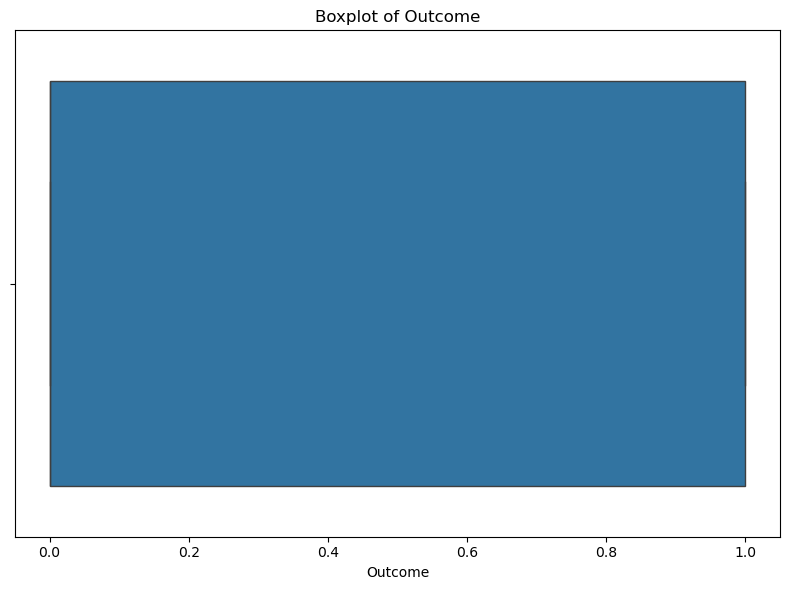

In [11]:
# Boxplot
for column in data.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=data[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

Text(0.5, 1.0, 'Diabetes Distribution')

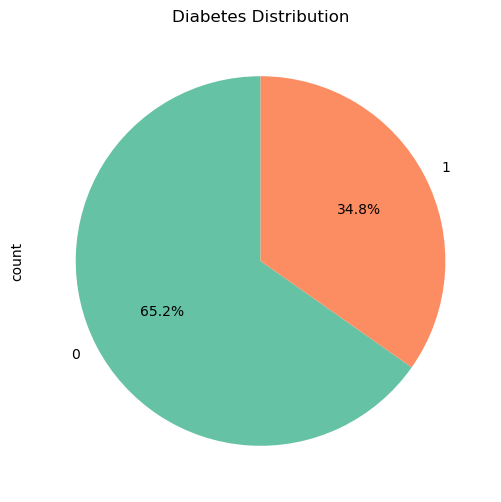

In [12]:
# Pie Chart for Outcome
plt.figure(figsize=(8, 6))
data['Outcome'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#66c2a5', '#fc8d62'])
plt.title('Diabetes Distribution')

## Bivariate Analysis

Text(0.5, 1.0, 'Correlation Matrix')

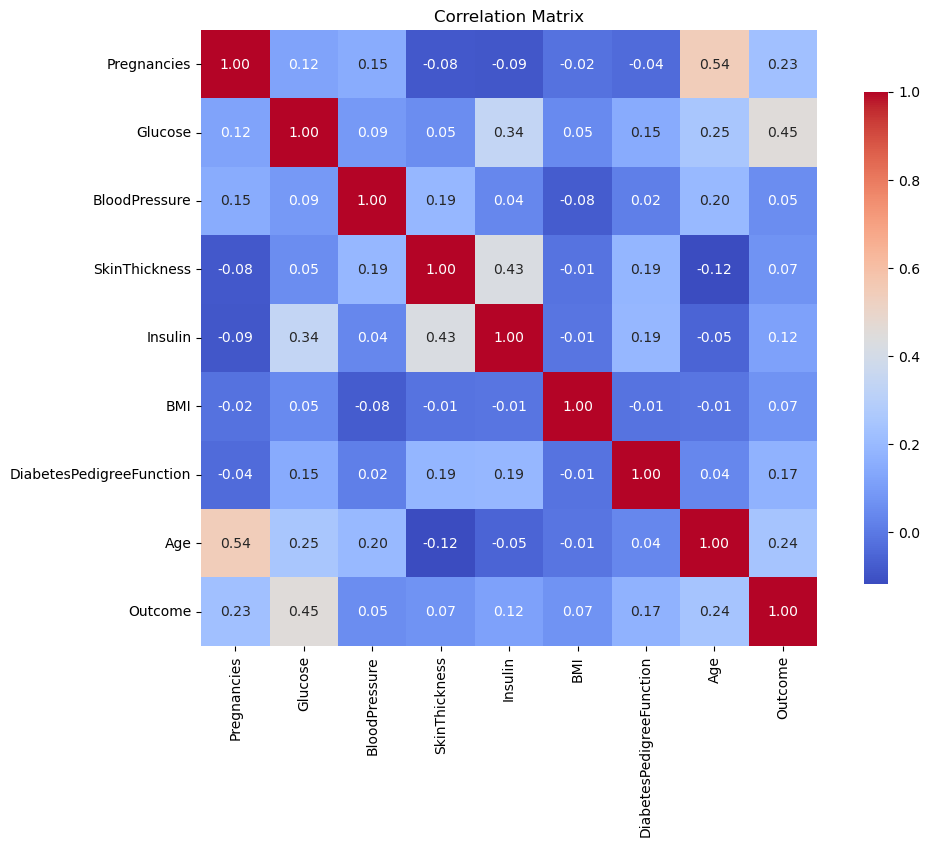

In [13]:
# Corelation Matrix
correlation_matrix = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix')

Text(0.5, 1.02, 'Pairplot of Diabetes Dataset')

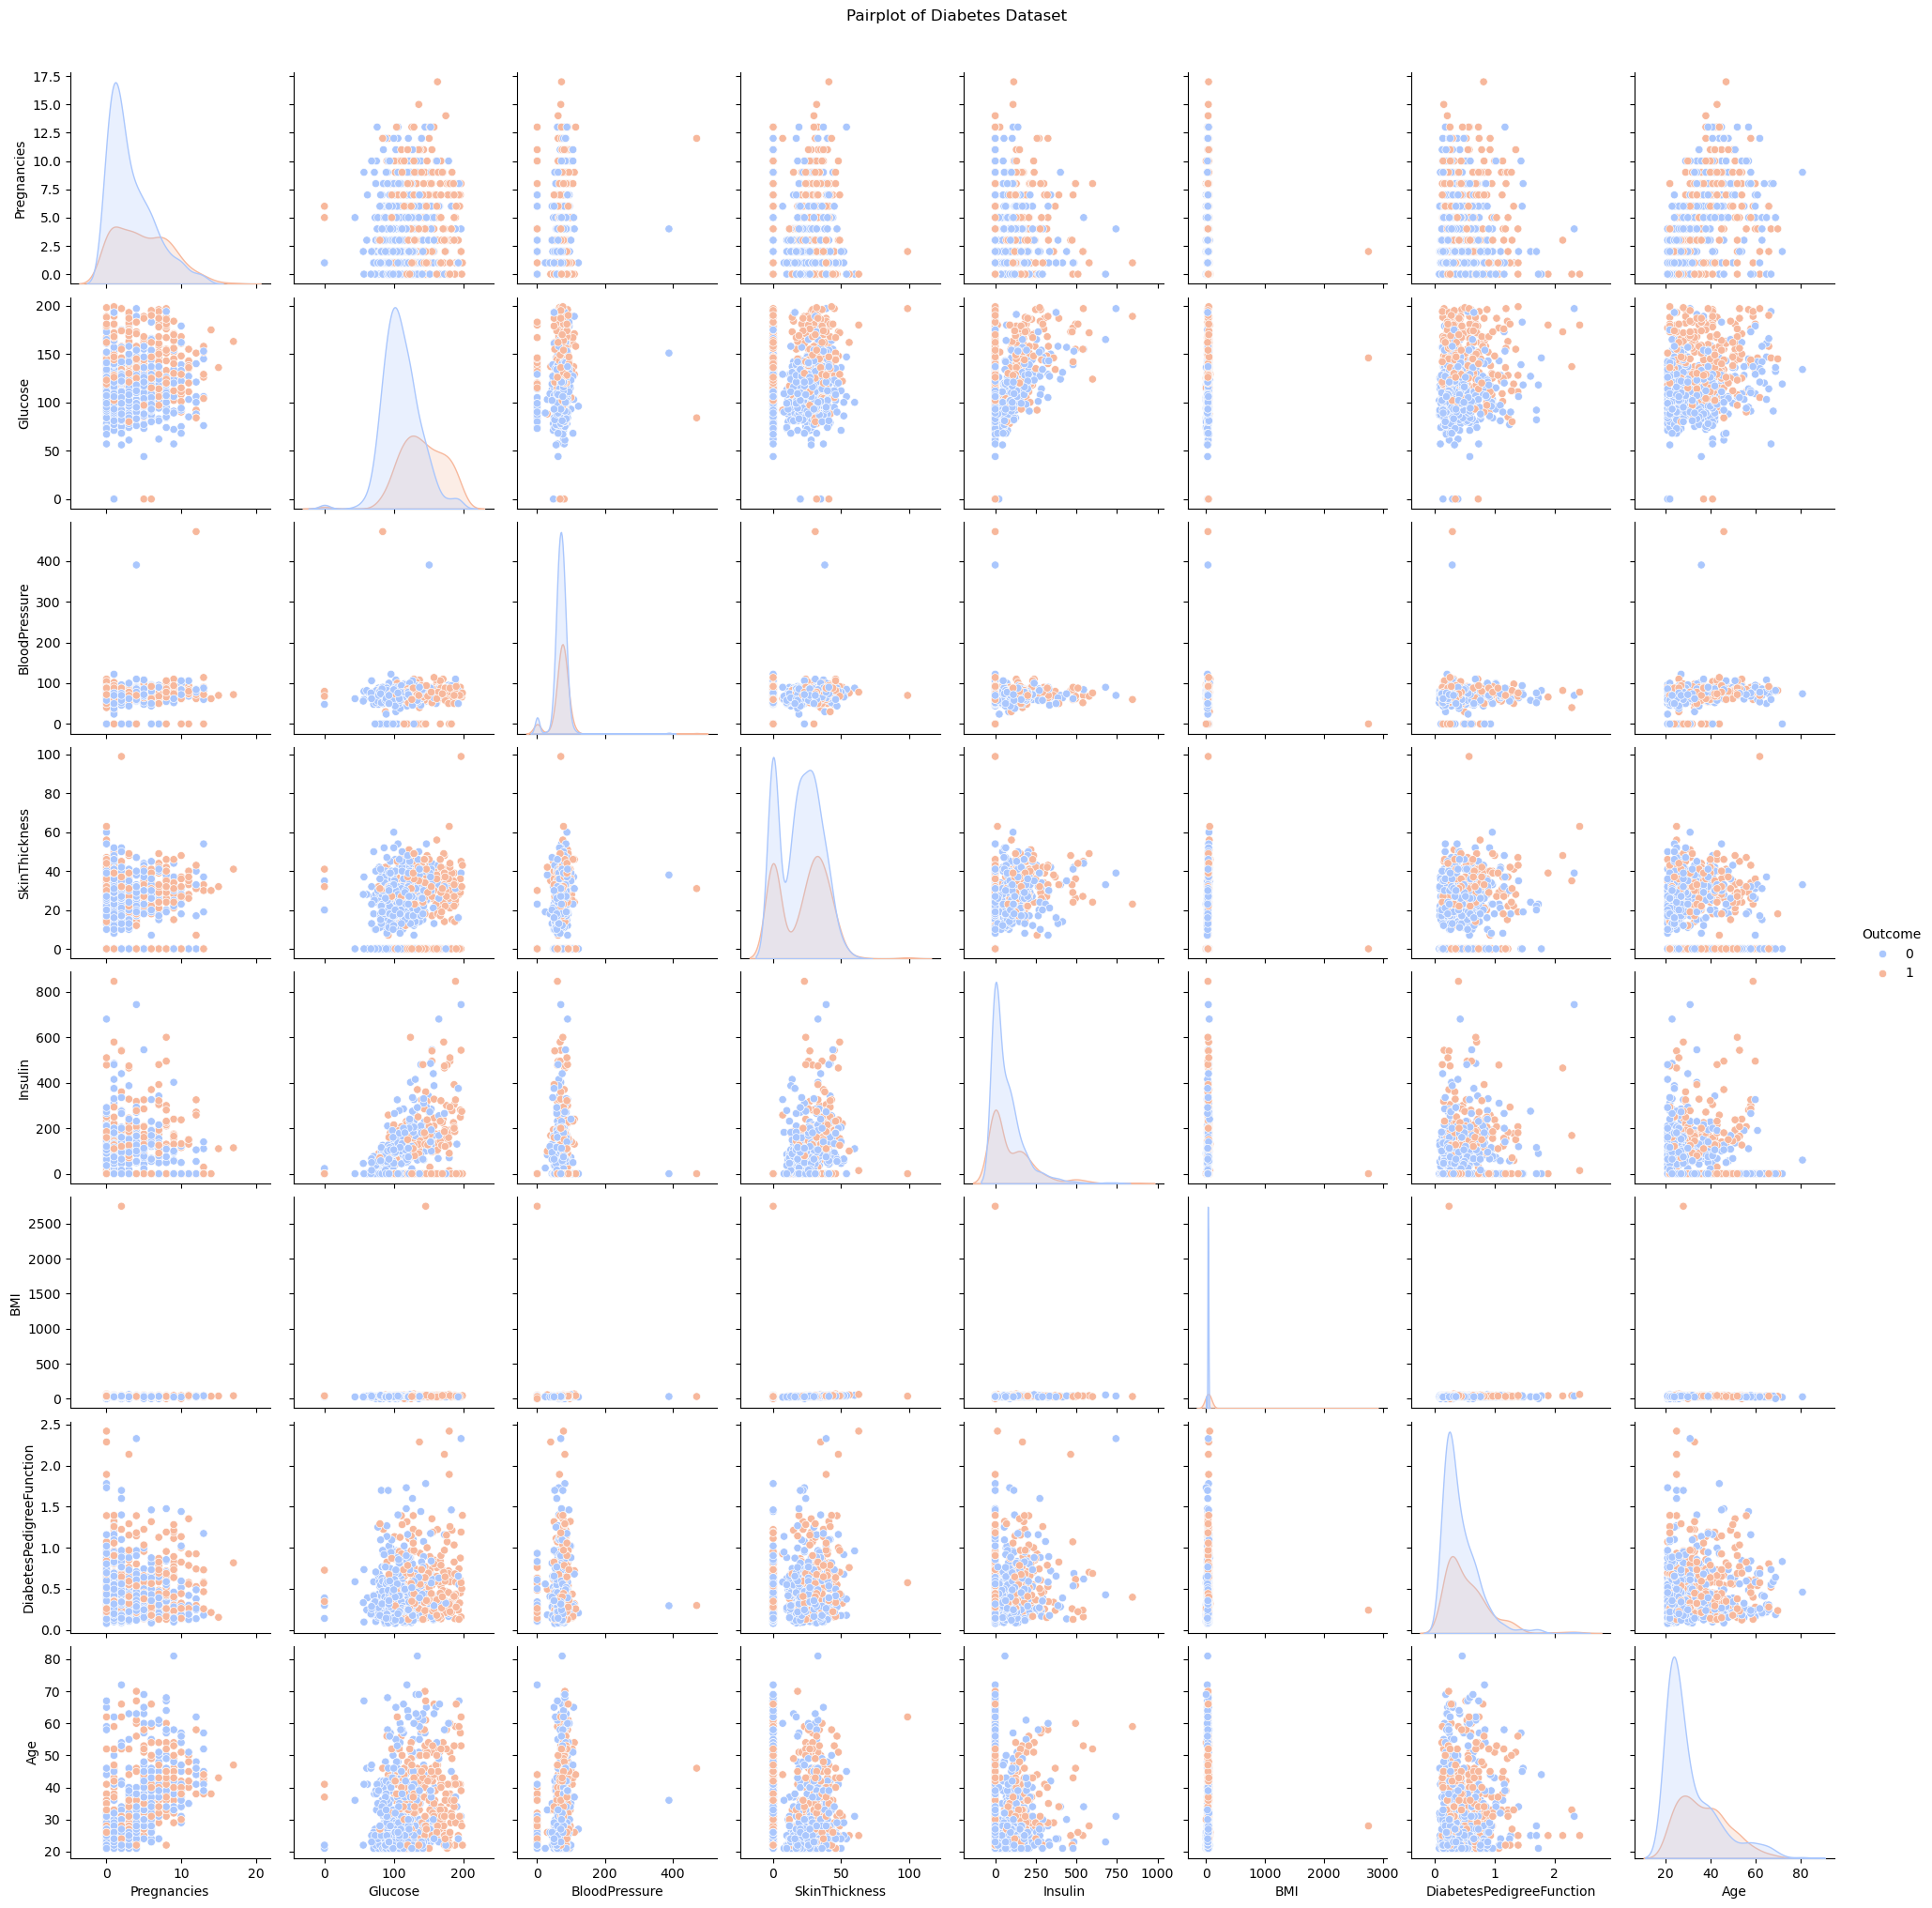

In [14]:
# Pairplot
sns.pairplot(data, hue='Outcome', palette='coolwarm', diag_kind='kde')
plt.suptitle('Pairplot of Diabetes Dataset', y=1.02)

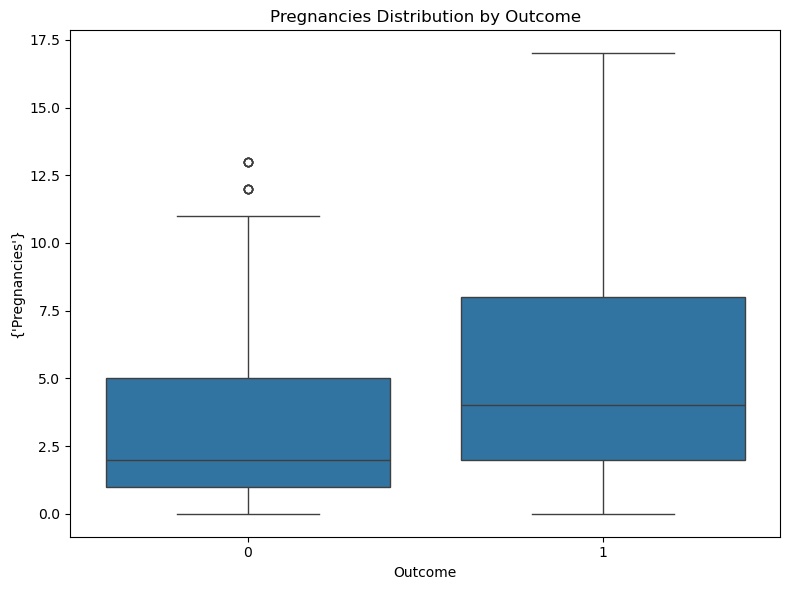

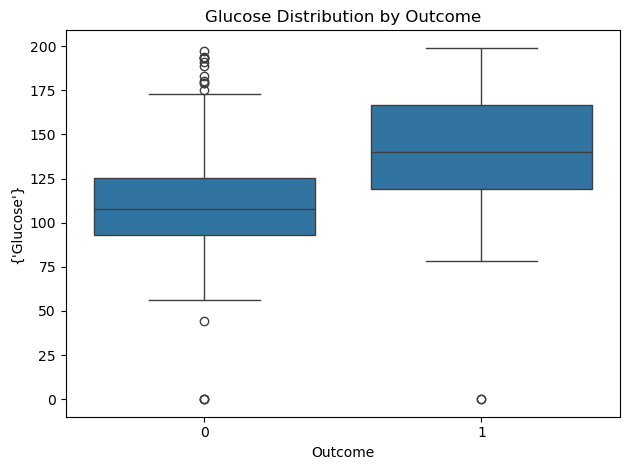

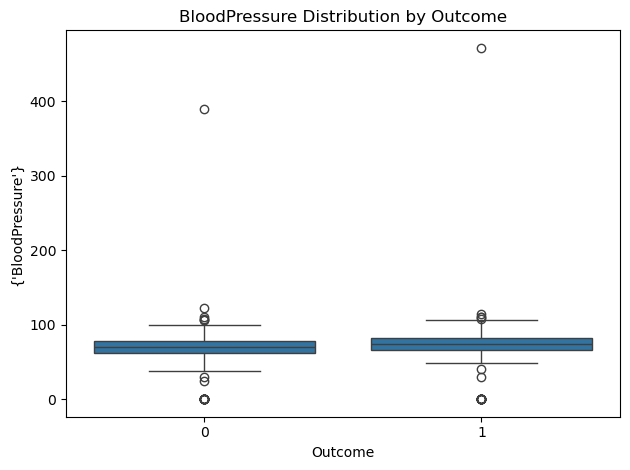

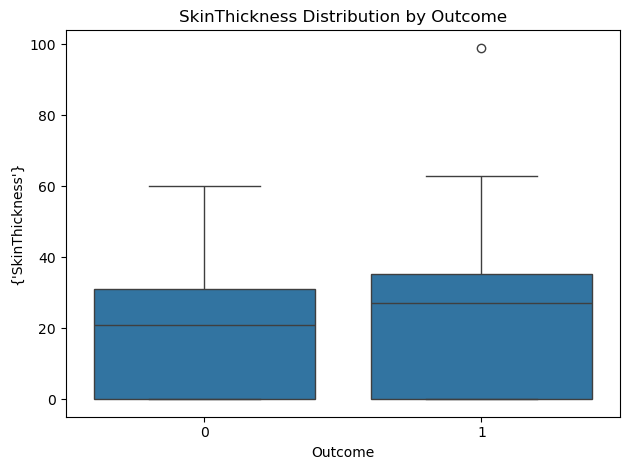

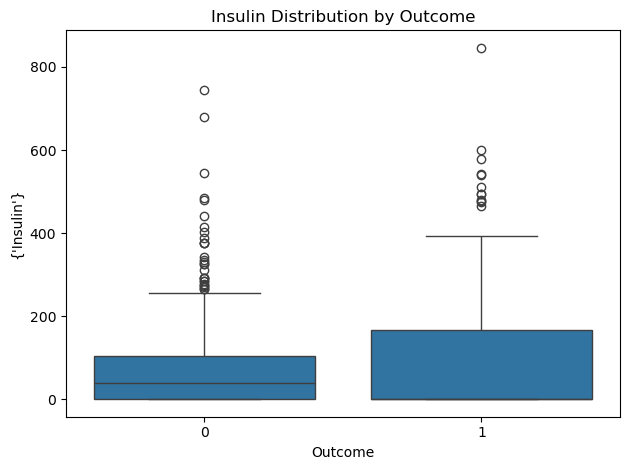

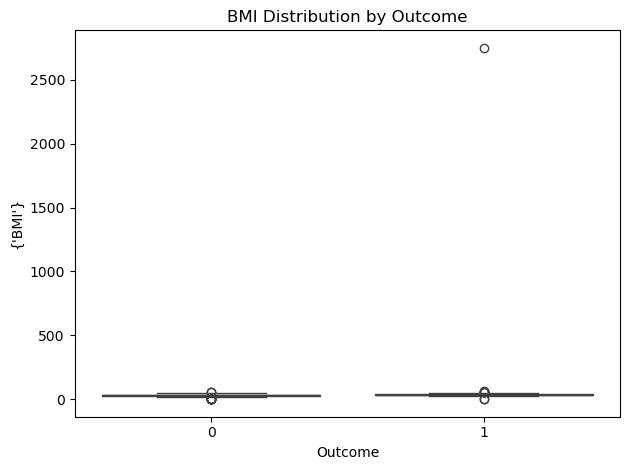

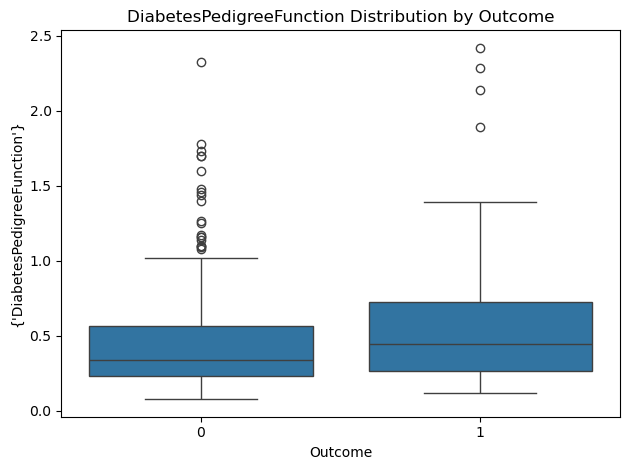

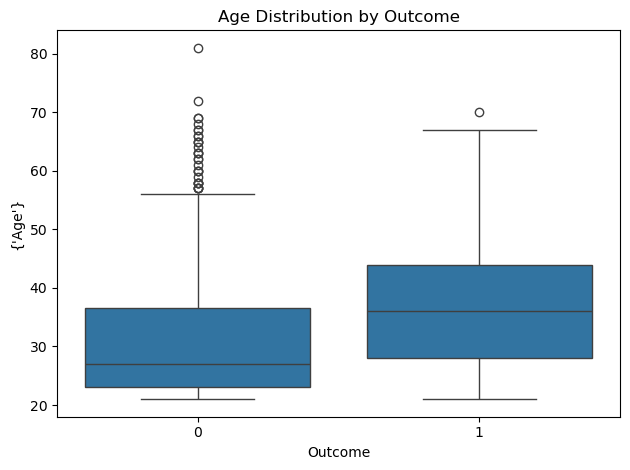

In [15]:
# Box Plot
plt.figure(figsize=(8, 6))
for column in data.drop('Outcome', axis=1).columns:
    sns.boxplot(x='Outcome', y=column, data=data)
    
    plt.title(f'{column} Distribution by Outcome')
    plt.xlabel('Outcome')
    plt.ylabel({column})

    # Show the plot
    plt.tight_layout()
    plt.show()


## Multivariate Analysis

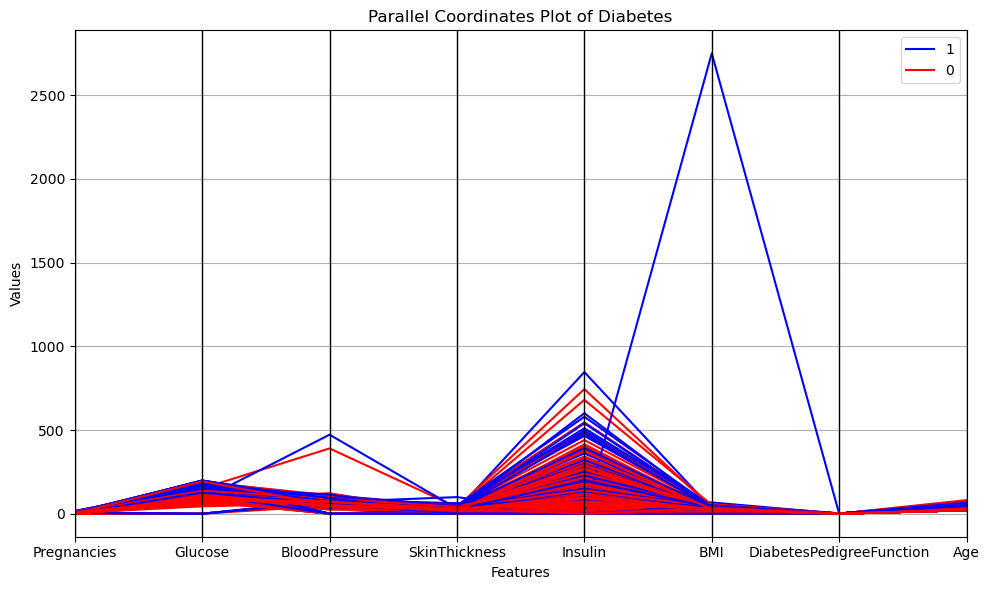

In [16]:
# Parallel Coordinate Plot
plt.figure(figsize=(10, 6))
parallel_coordinates(data, 'Outcome', color=['blue', 'red'])
plt.title('Parallel Coordinates Plot of Diabetes')
plt.xlabel('Features')
plt.ylabel('Values')
plt.grid(True)
plt.tight_layout()
plt.show()


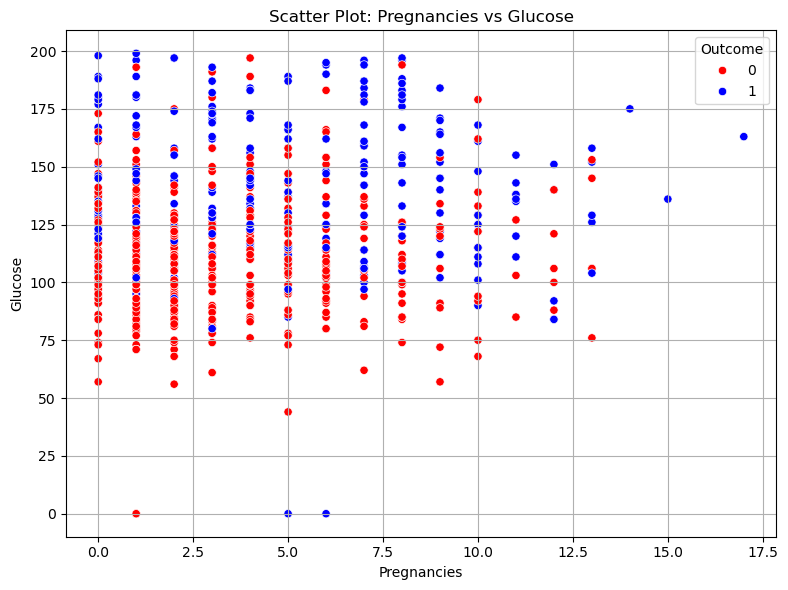

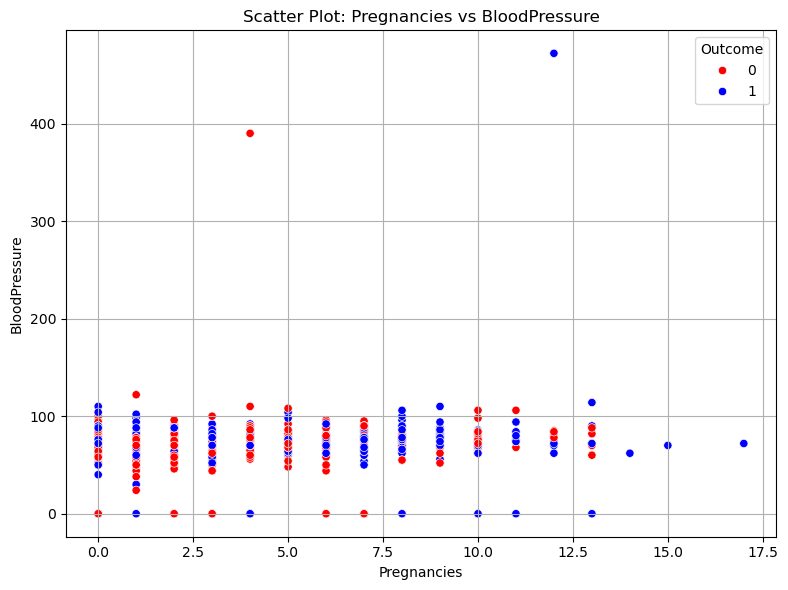

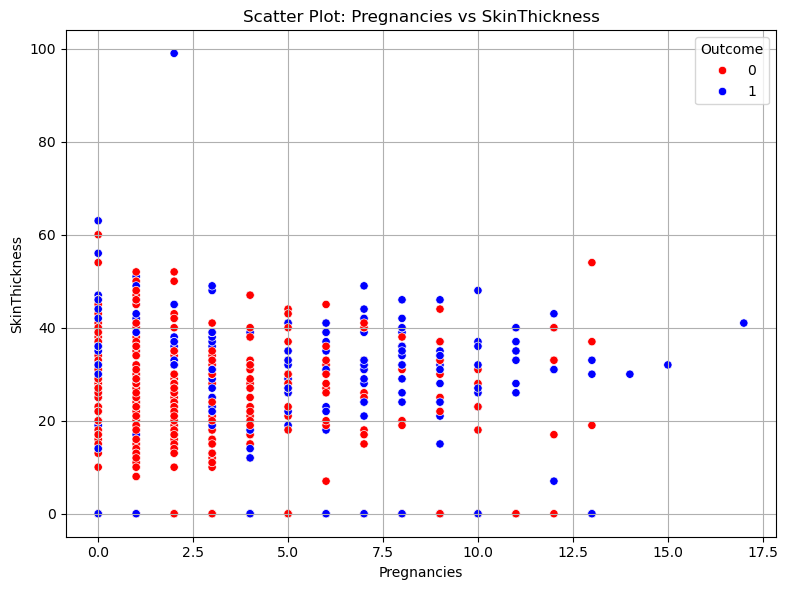

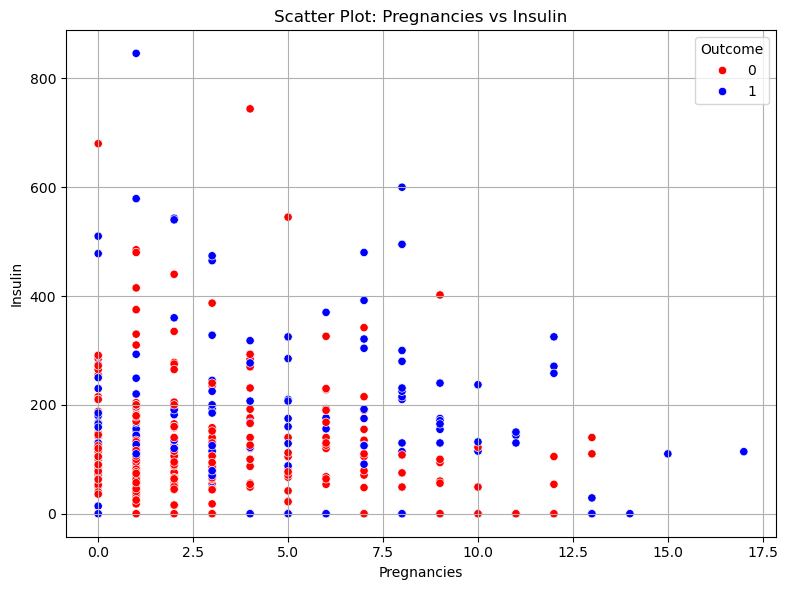

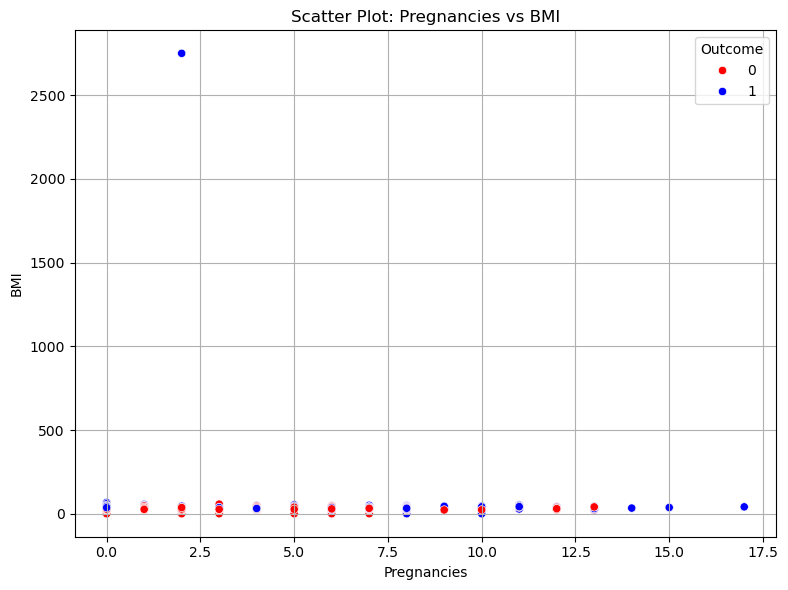

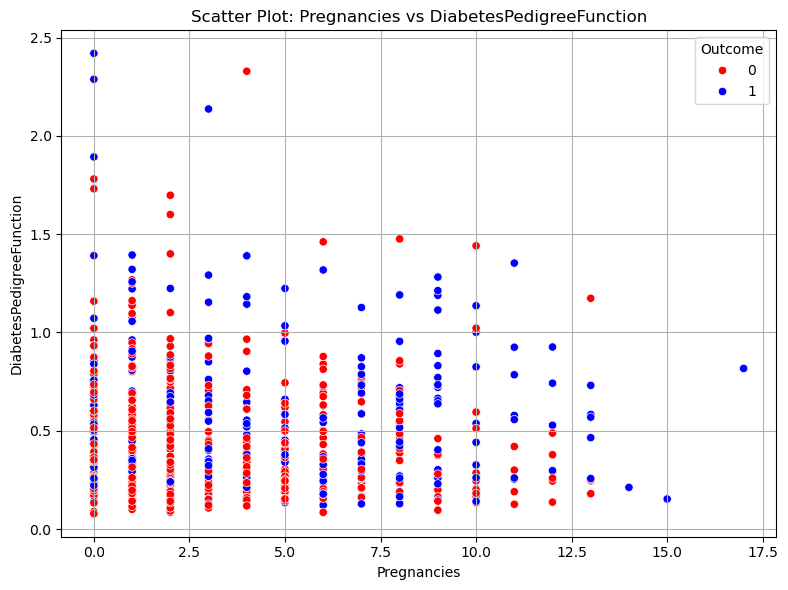

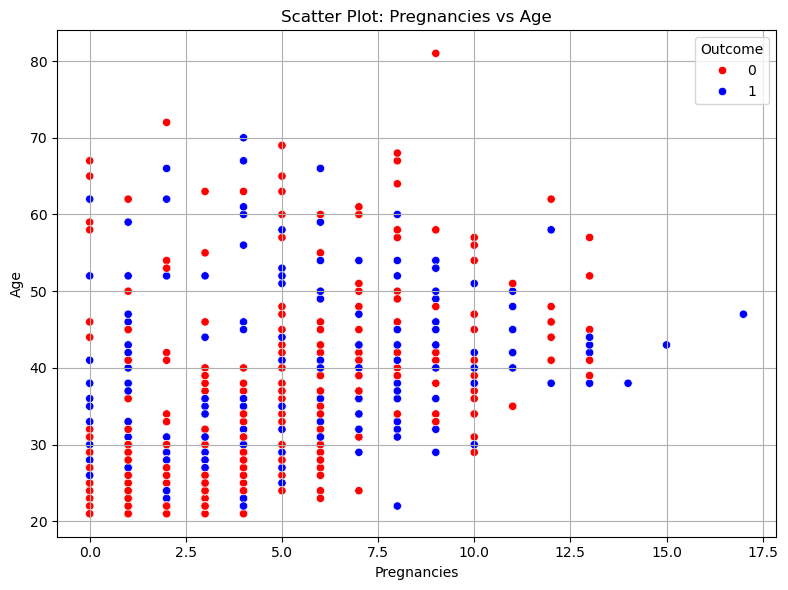

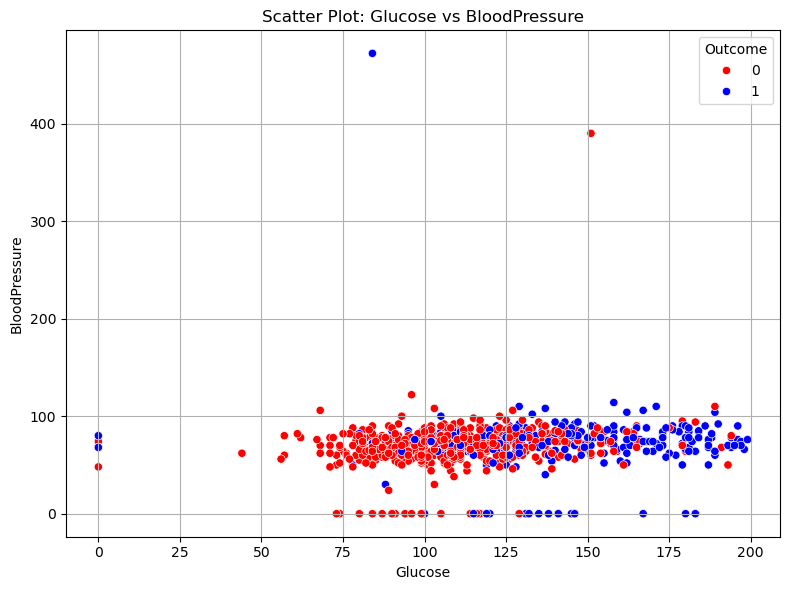

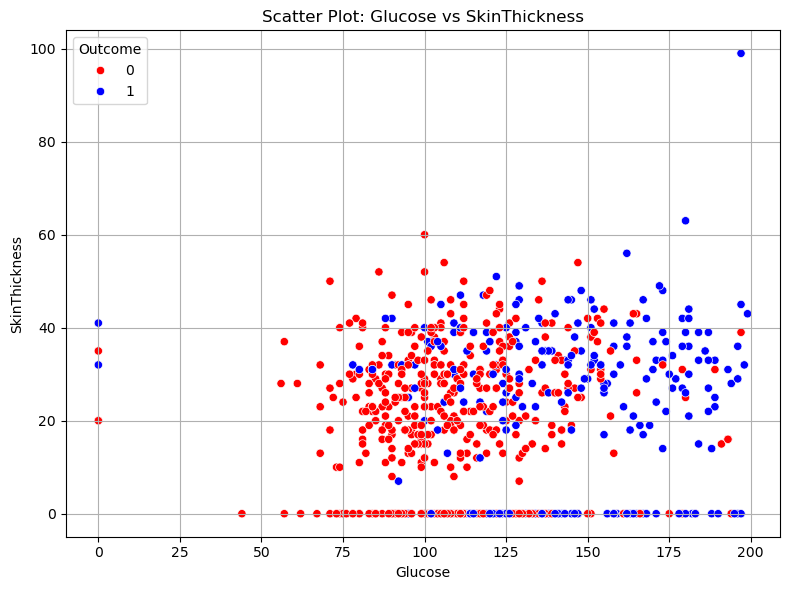

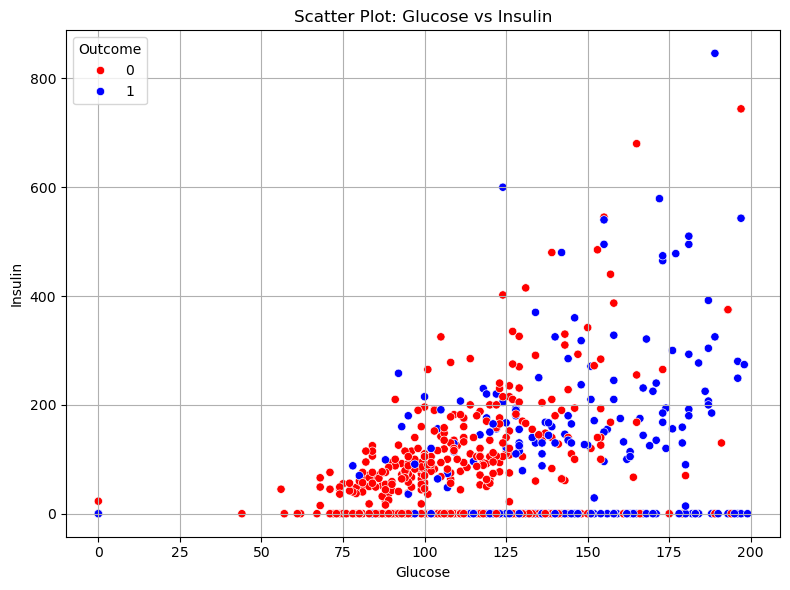

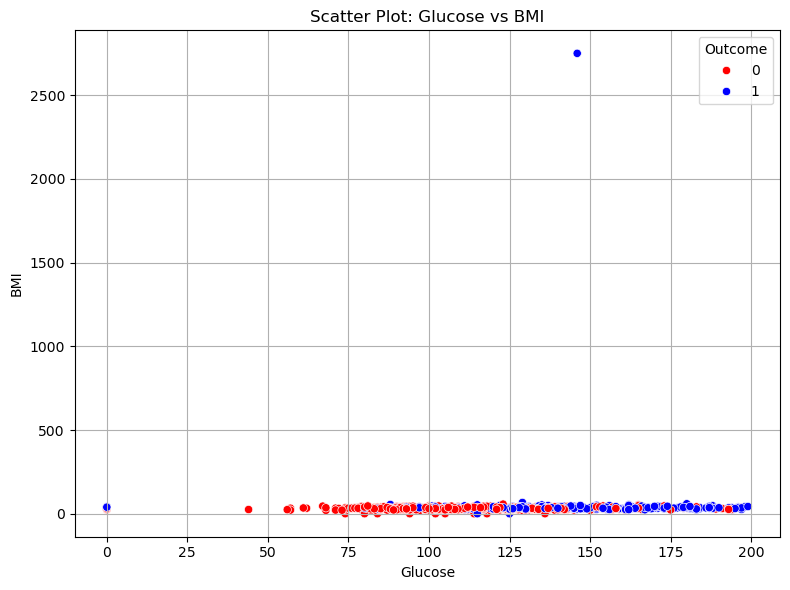

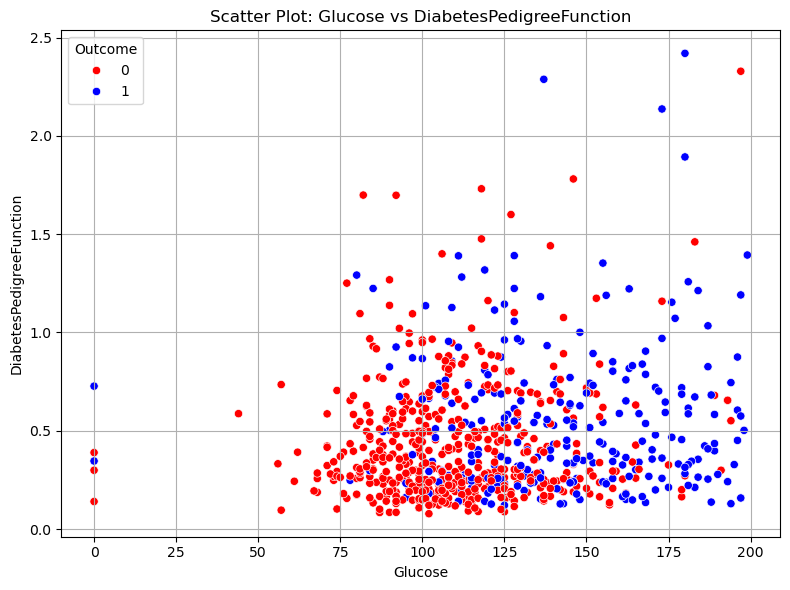

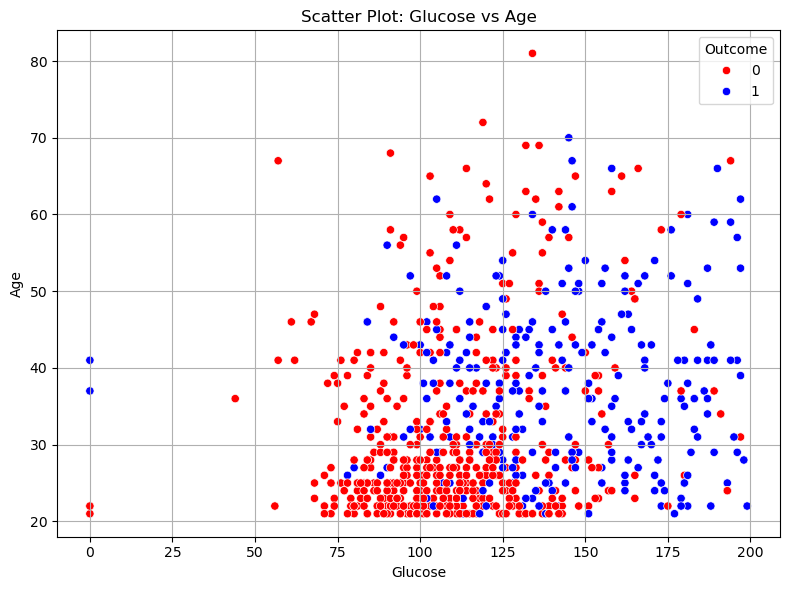

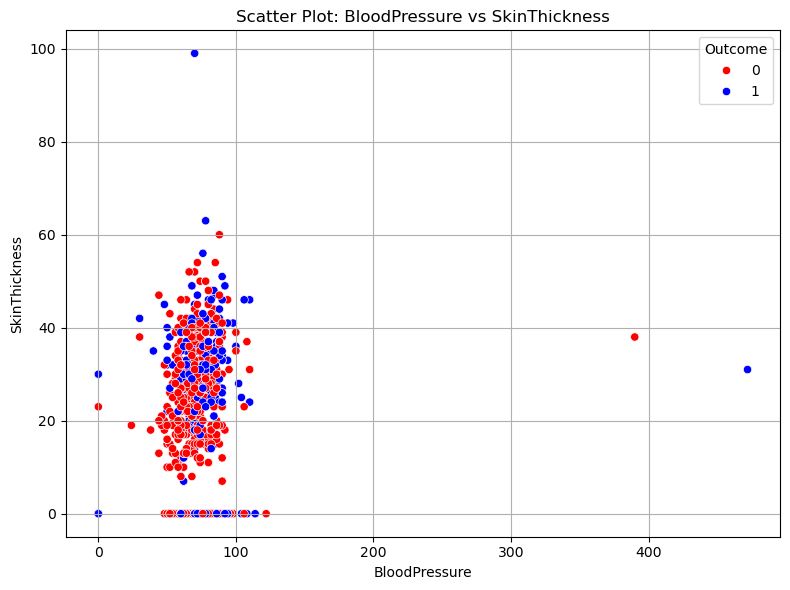

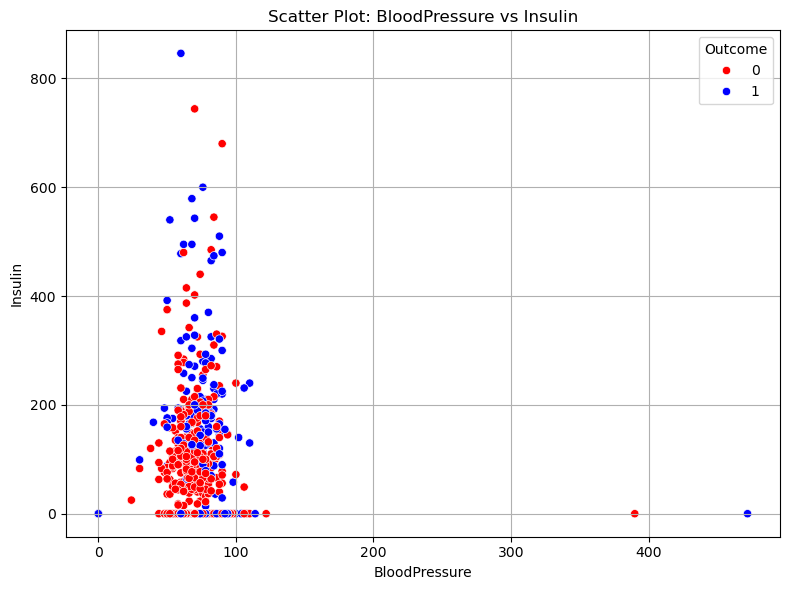

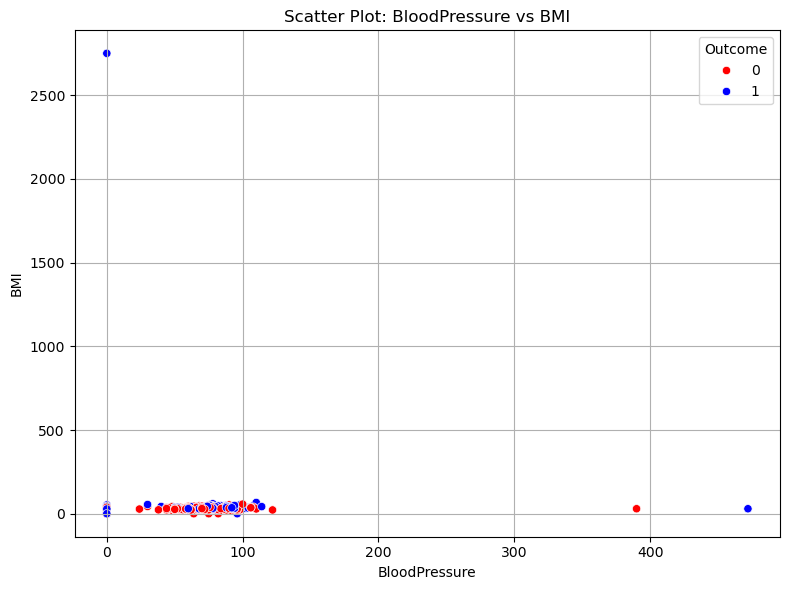

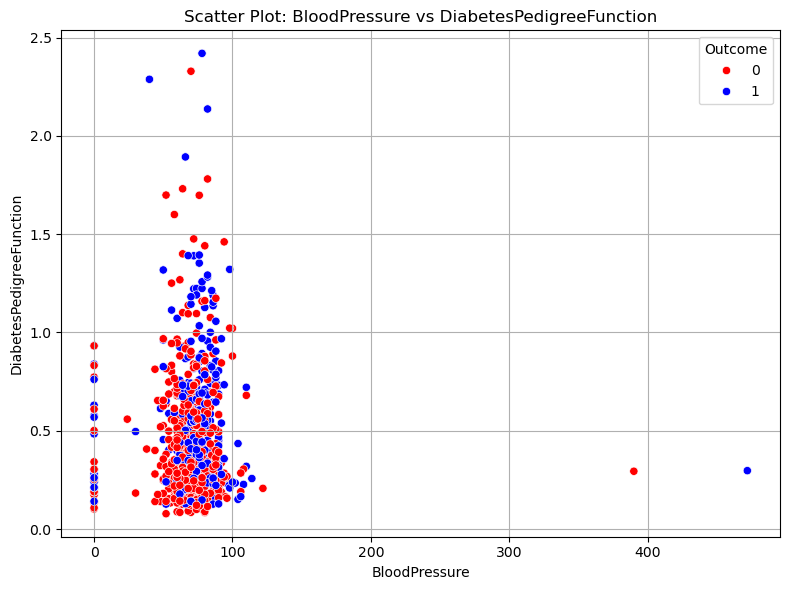

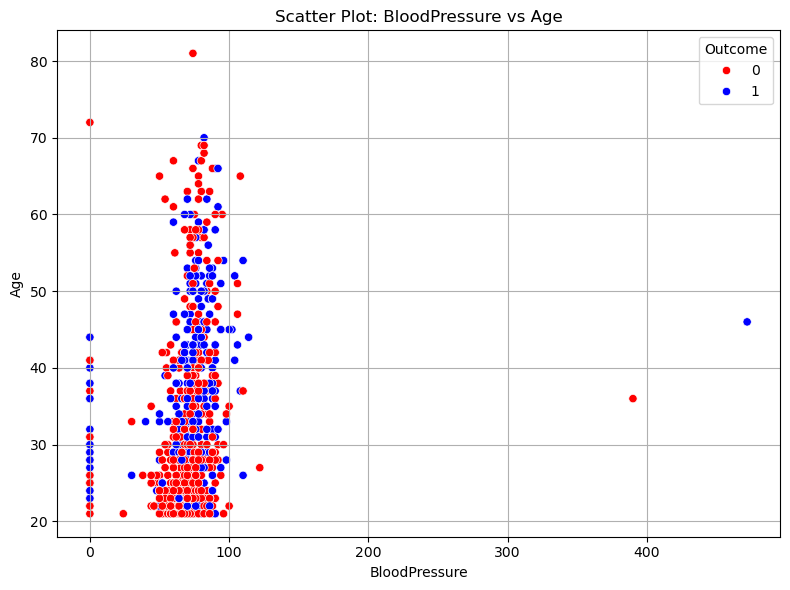

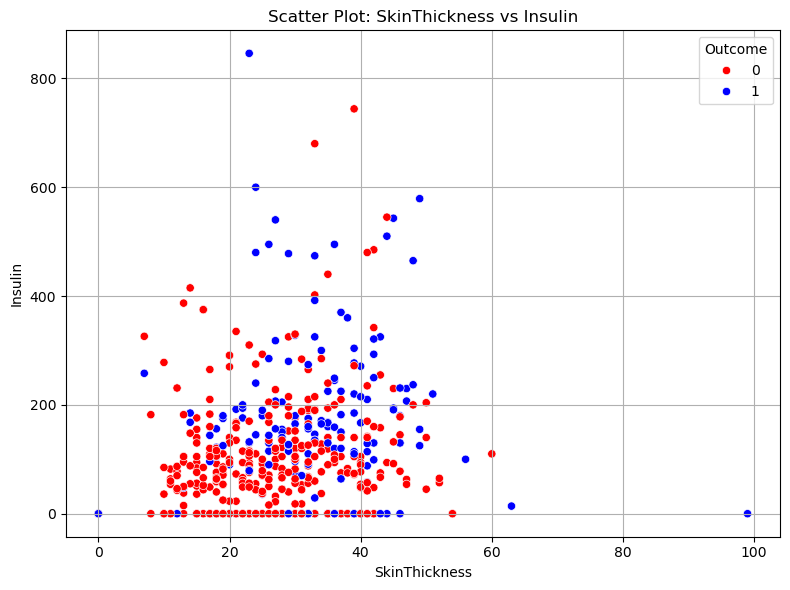

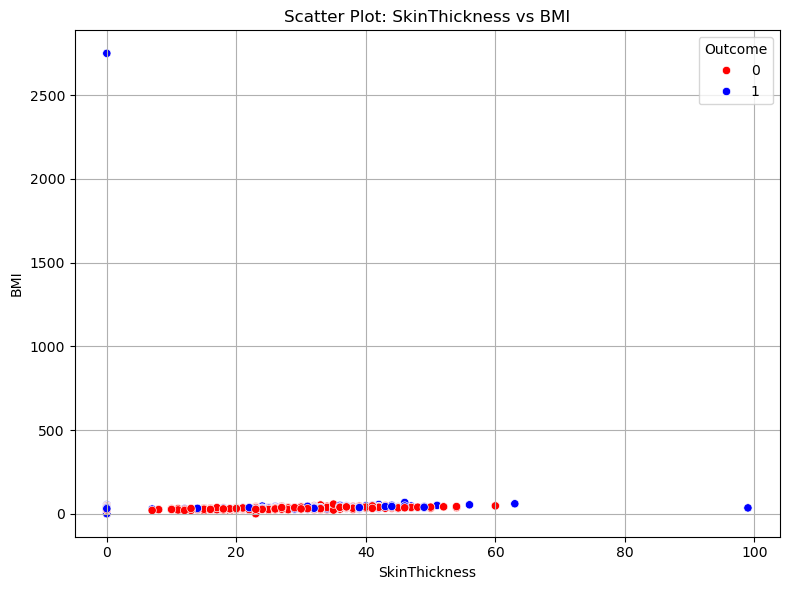

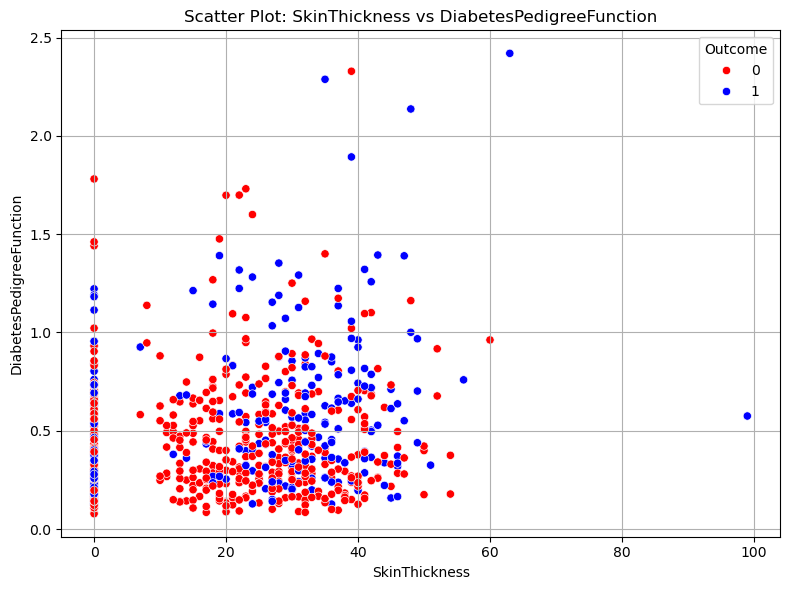

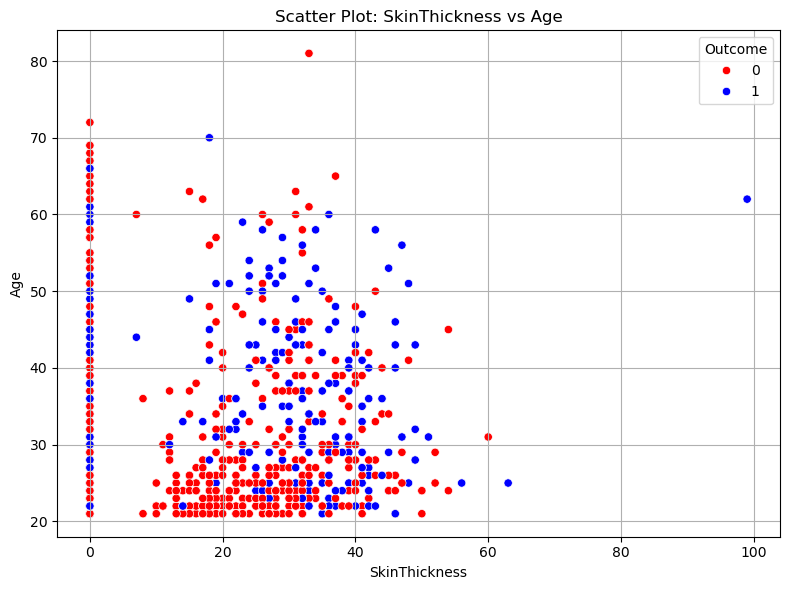

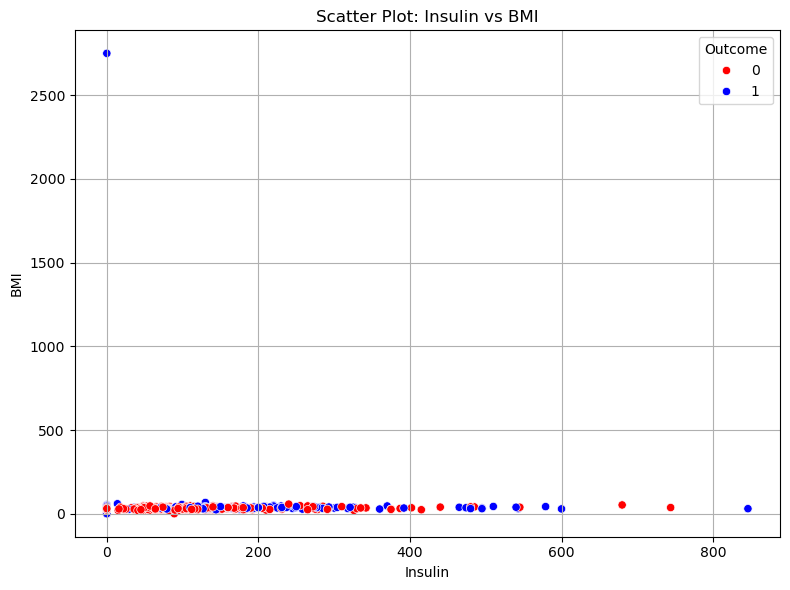

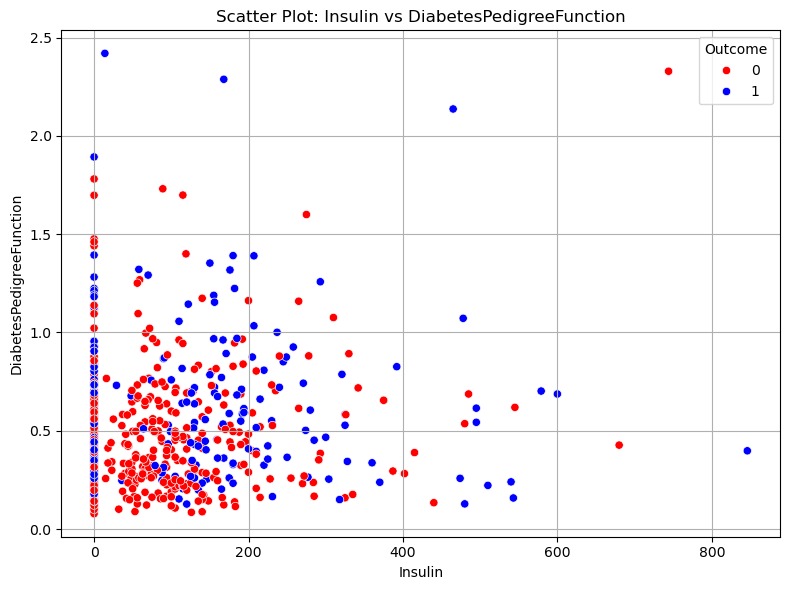

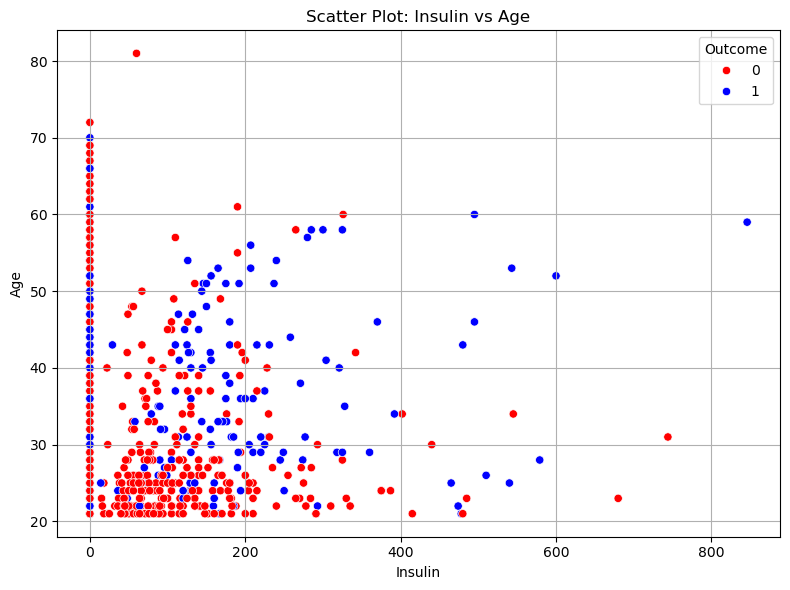

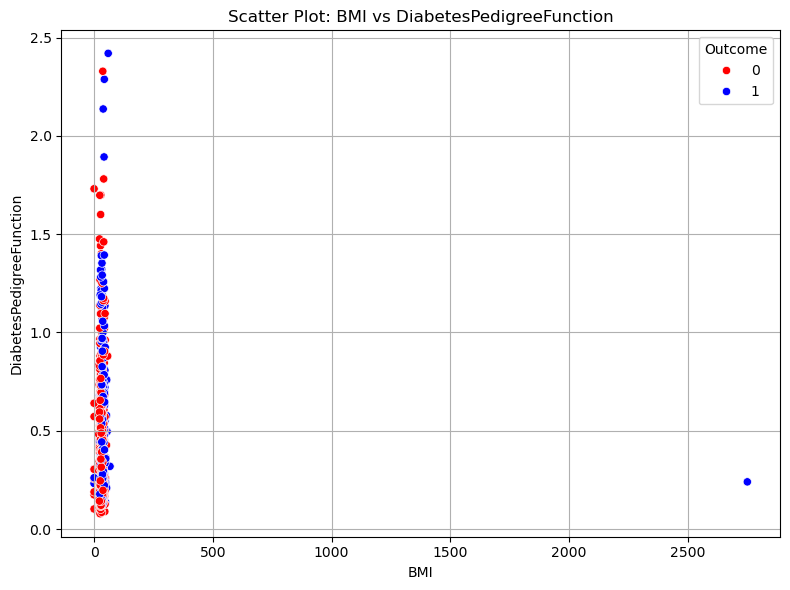

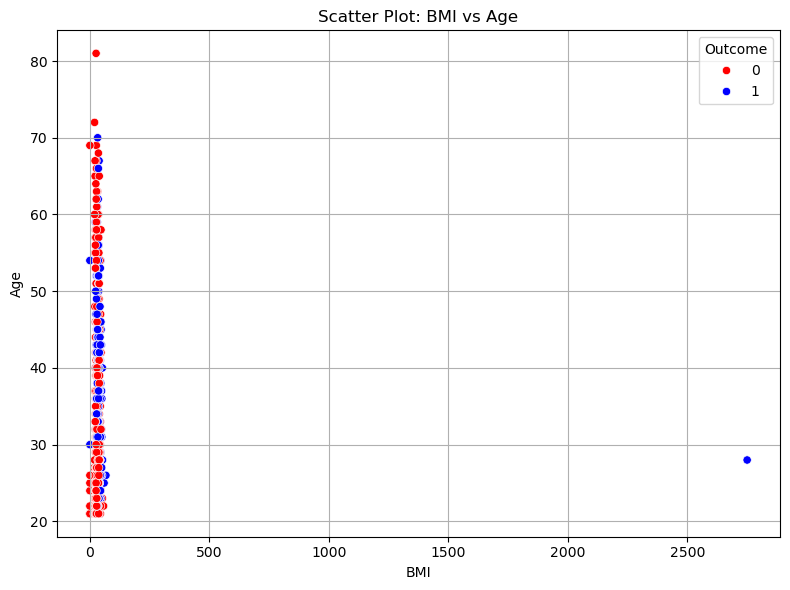

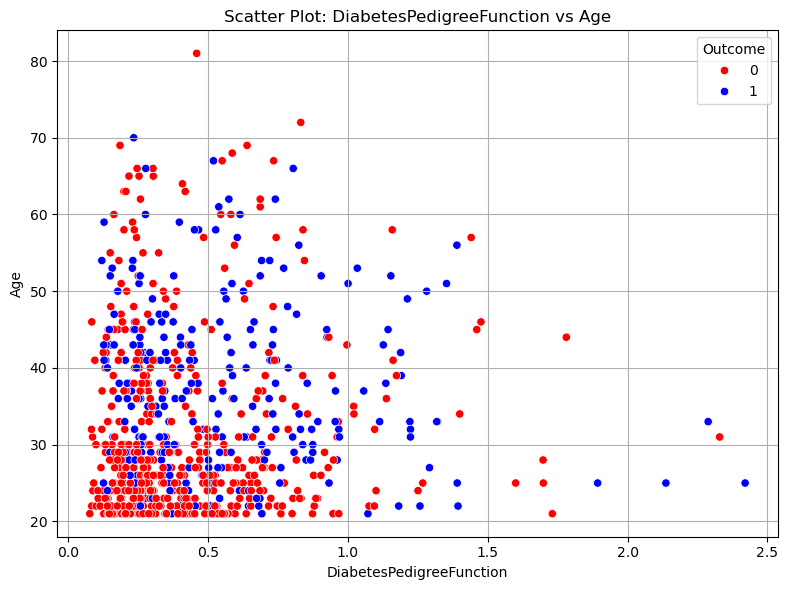

In [17]:
# PCA-Based Visualisation
import itertools

# List of the 8 features
features = data.drop('Outcome', axis=1).columns

# Generate all unique pairs of features
feature_pairs = list(itertools.combinations(features, 2))

# Create scatter plots for each pair
for x_feature, y_feature in feature_pairs:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=data,
        x=x_feature,
        y=y_feature,
        hue='Outcome',
        palette={1: 'blue', 0: 'red'}
    )
    plt.title(f'Scatter Plot: {x_feature} vs {y_feature}')
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Data Preparation

## Impute Data


### Cleaning Data

In [18]:
# Copy the original data set
data_copy = data.copy()

# Identify all row that are duplicates and only keeping the first row
data_cleaned = data_copy.drop_duplicates(keep='first')

# Find all duplicate rows (keeps first occurrence)
duplicate_mask = data.duplicated(keep='first')
deleted_row_numbers = data[duplicate_mask].index.tolist()

print(f"Deleted row numbers: {deleted_row_numbers}")
print(f"Number of deleted rows: {len(deleted_row_numbers)}")

Deleted row numbers: [532, 707, 716, 718, 770]
Number of deleted rows: 5


In [19]:
outlier_summary = {}

for col in ['BloodPressure', 'BMI', ]:
    if data_cleaned[col].notna().sum() > 0:
        # Calculate Z-score for outlier detection
        z_scores = np.abs(stats.zscore(data_cleaned[col].dropna()))
        z_outliers = z_scores > 3
        
        outlier_summary[col] = {
            'z_score_outliers': z_outliers.sum(),
            'range': f"{data_cleaned[col].min():.1f} - {data_cleaned[col].max():.1f}"
        }
        
        print(f"{col}: Z-score outliers: {z_outliers.sum()}")

BloodPressure: Z-score outliers: 2
BMI: Z-score outliers: 1


In [20]:
# Set invalid / incorrect values to NaN
invalid_zero_col = ['Glucose', 'BloodPressure', 'BMI']
data_cleaned.loc[:, invalid_zero_col] = data_cleaned.loc[:, invalid_zero_col].replace(0, np.nan)

## Data Splitting

In [21]:
from sklearn.model_selection import train_test_split

X = data_cleaned.drop('Outcome', axis=1)
y = data_cleaned['Outcome']

# 1st split: 80% train_val, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2nd split: from train_val, split 75% train, 25% val (75% of 80% = 60%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

In [22]:
# Standardized dataframe
scaler = StandardScaler()

data_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=X_train.columns, 
    index=X_train.index
)

In [23]:
# Setting Outliers in BMI and BloodPressure to NaN
data_no_outlier = data_scaled.copy()

for col in ['BloodPressure', 'BMI']:
    outlier_mask = np.abs(data_no_outlier[col]) > 3
    
    data_no_outlier.loc[outlier_mask, col] = np.nan

    print(f"{col}: Changed at {data_no_outlier[outlier_mask].index.tolist()}")

BloodPressure: Changed at [556]
BMI: Changed at [668]


In [24]:
# Undoing Standardization
data_unscaled = pd.DataFrame(
    scaler.inverse_transform(data_scaled),
    columns=data_scaled.columns,
    index=data_scaled.index
)

data_no_outlier_unscaled = pd.DataFrame(
    scaler.inverse_transform(data_no_outlier),
    columns=data_no_outlier.columns,
    index=data_no_outlier.index
)

### Relationship between Columns

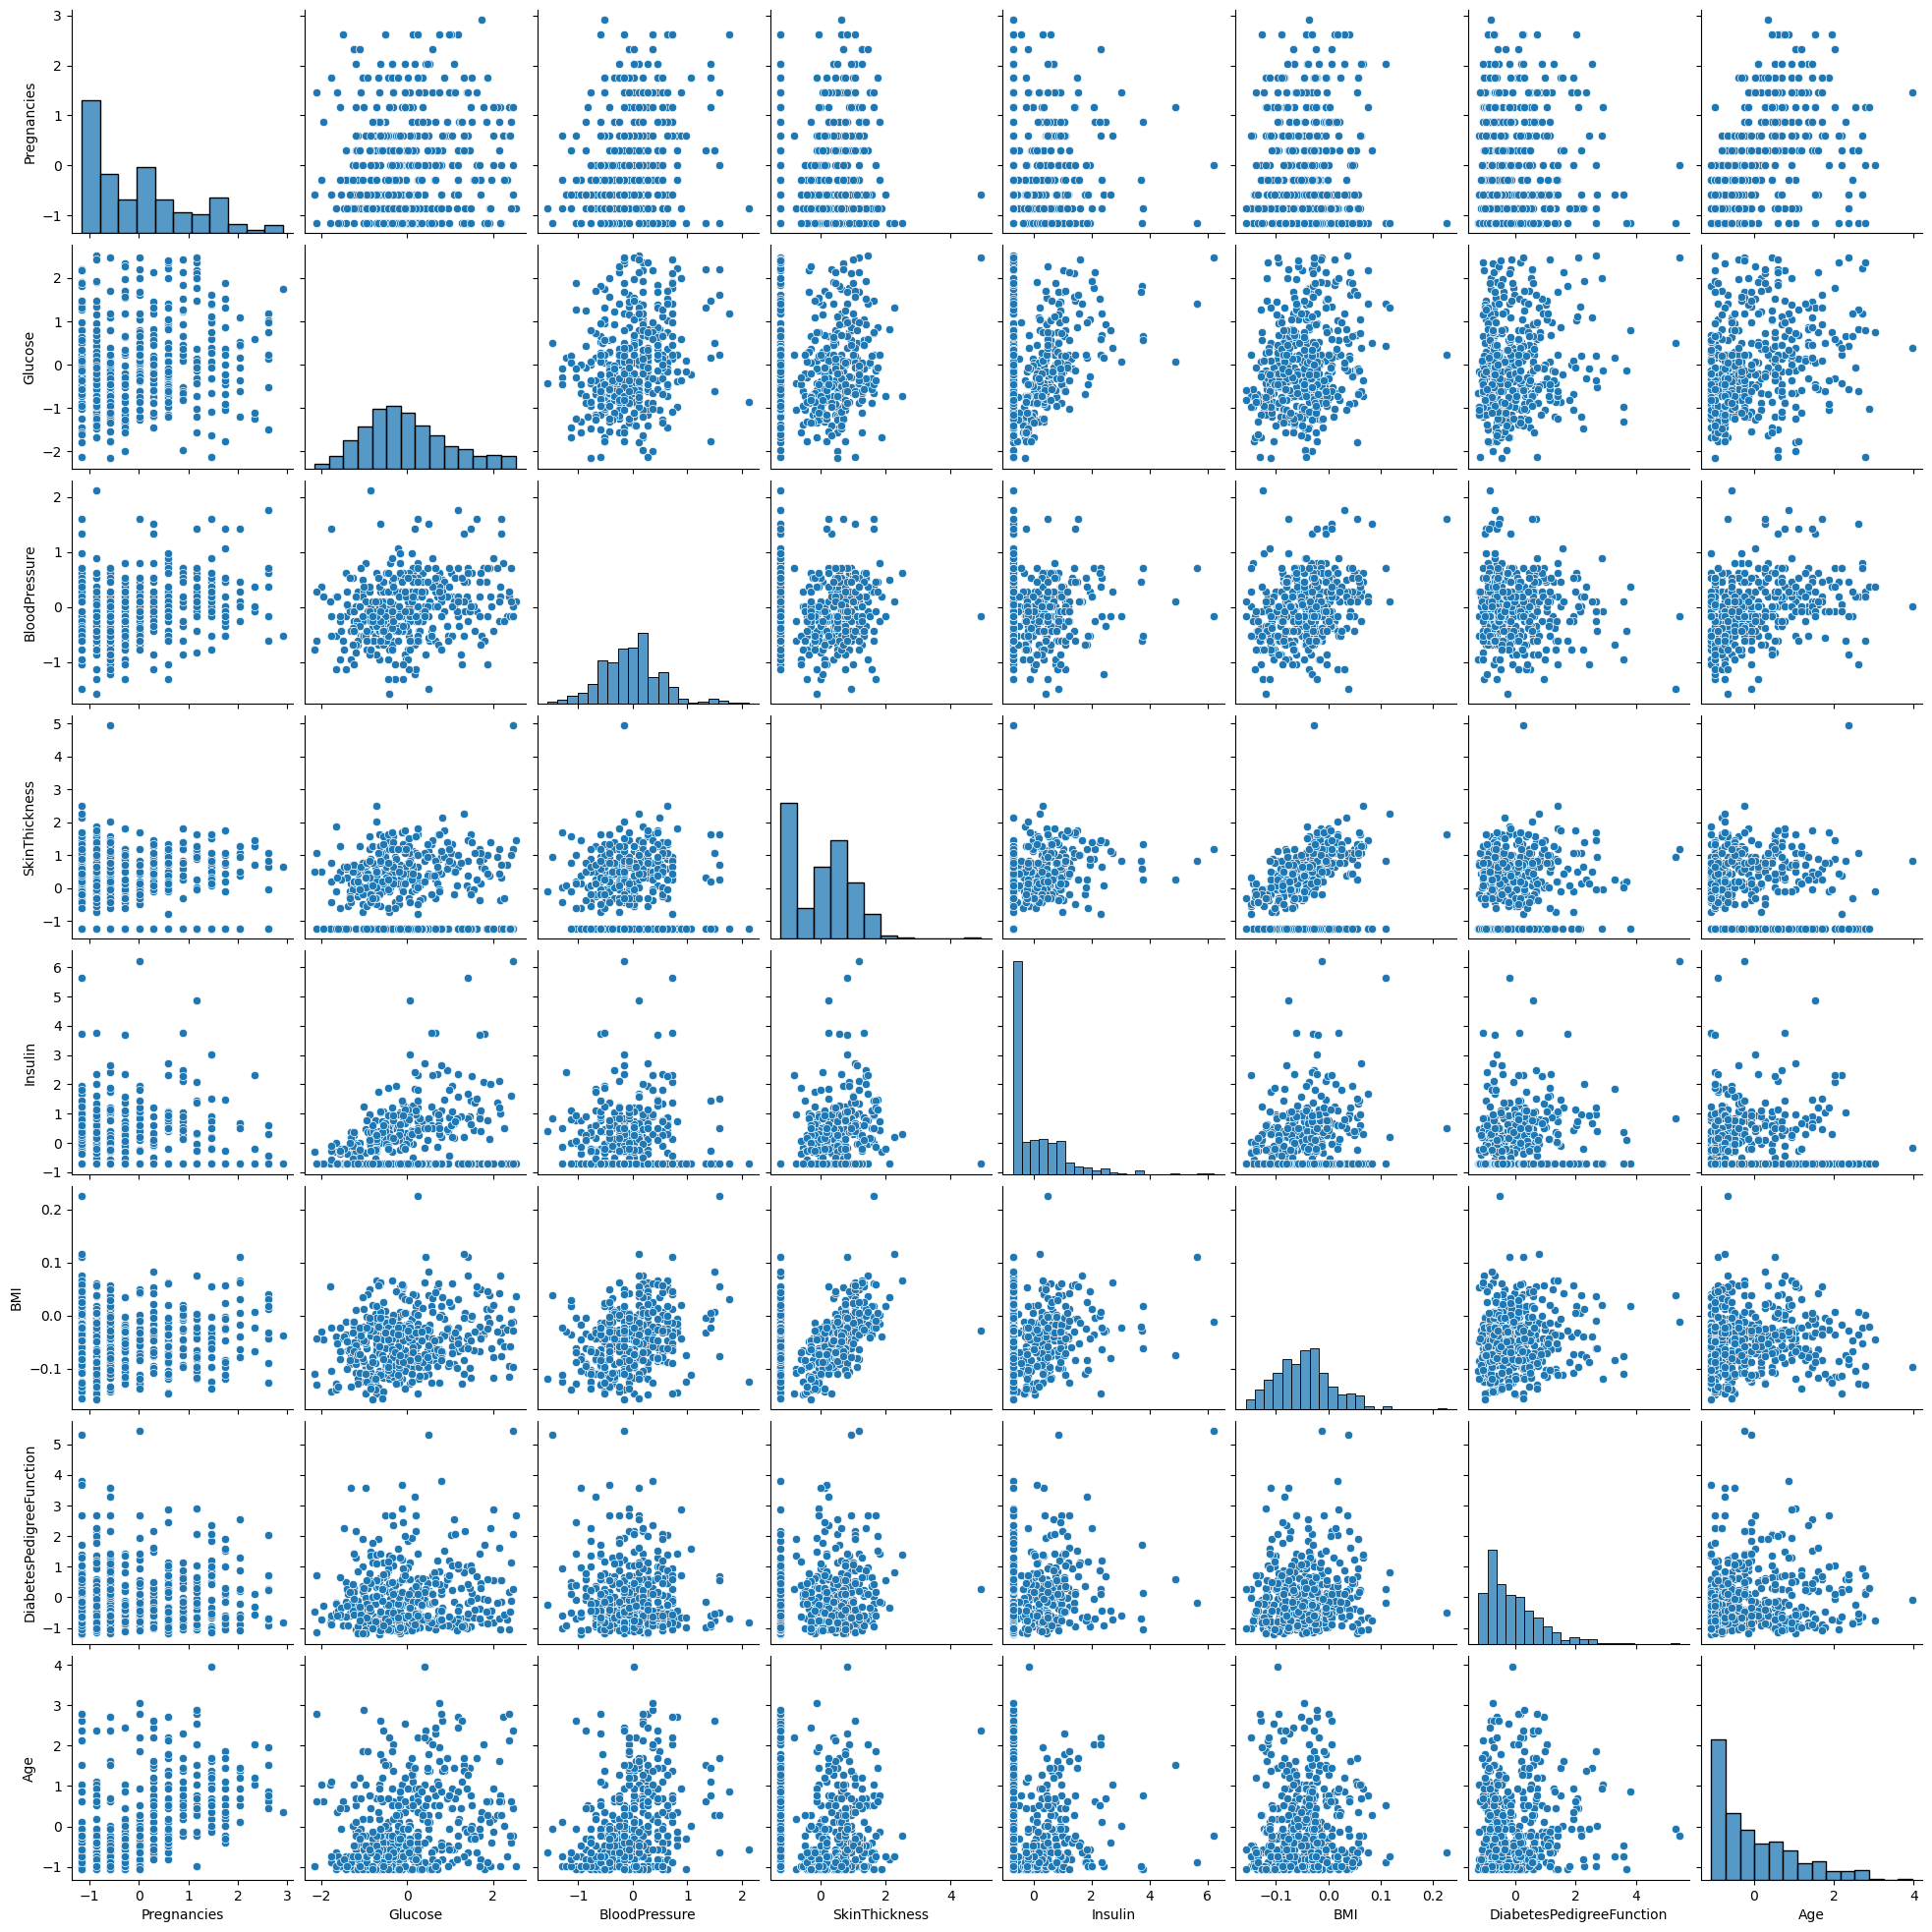

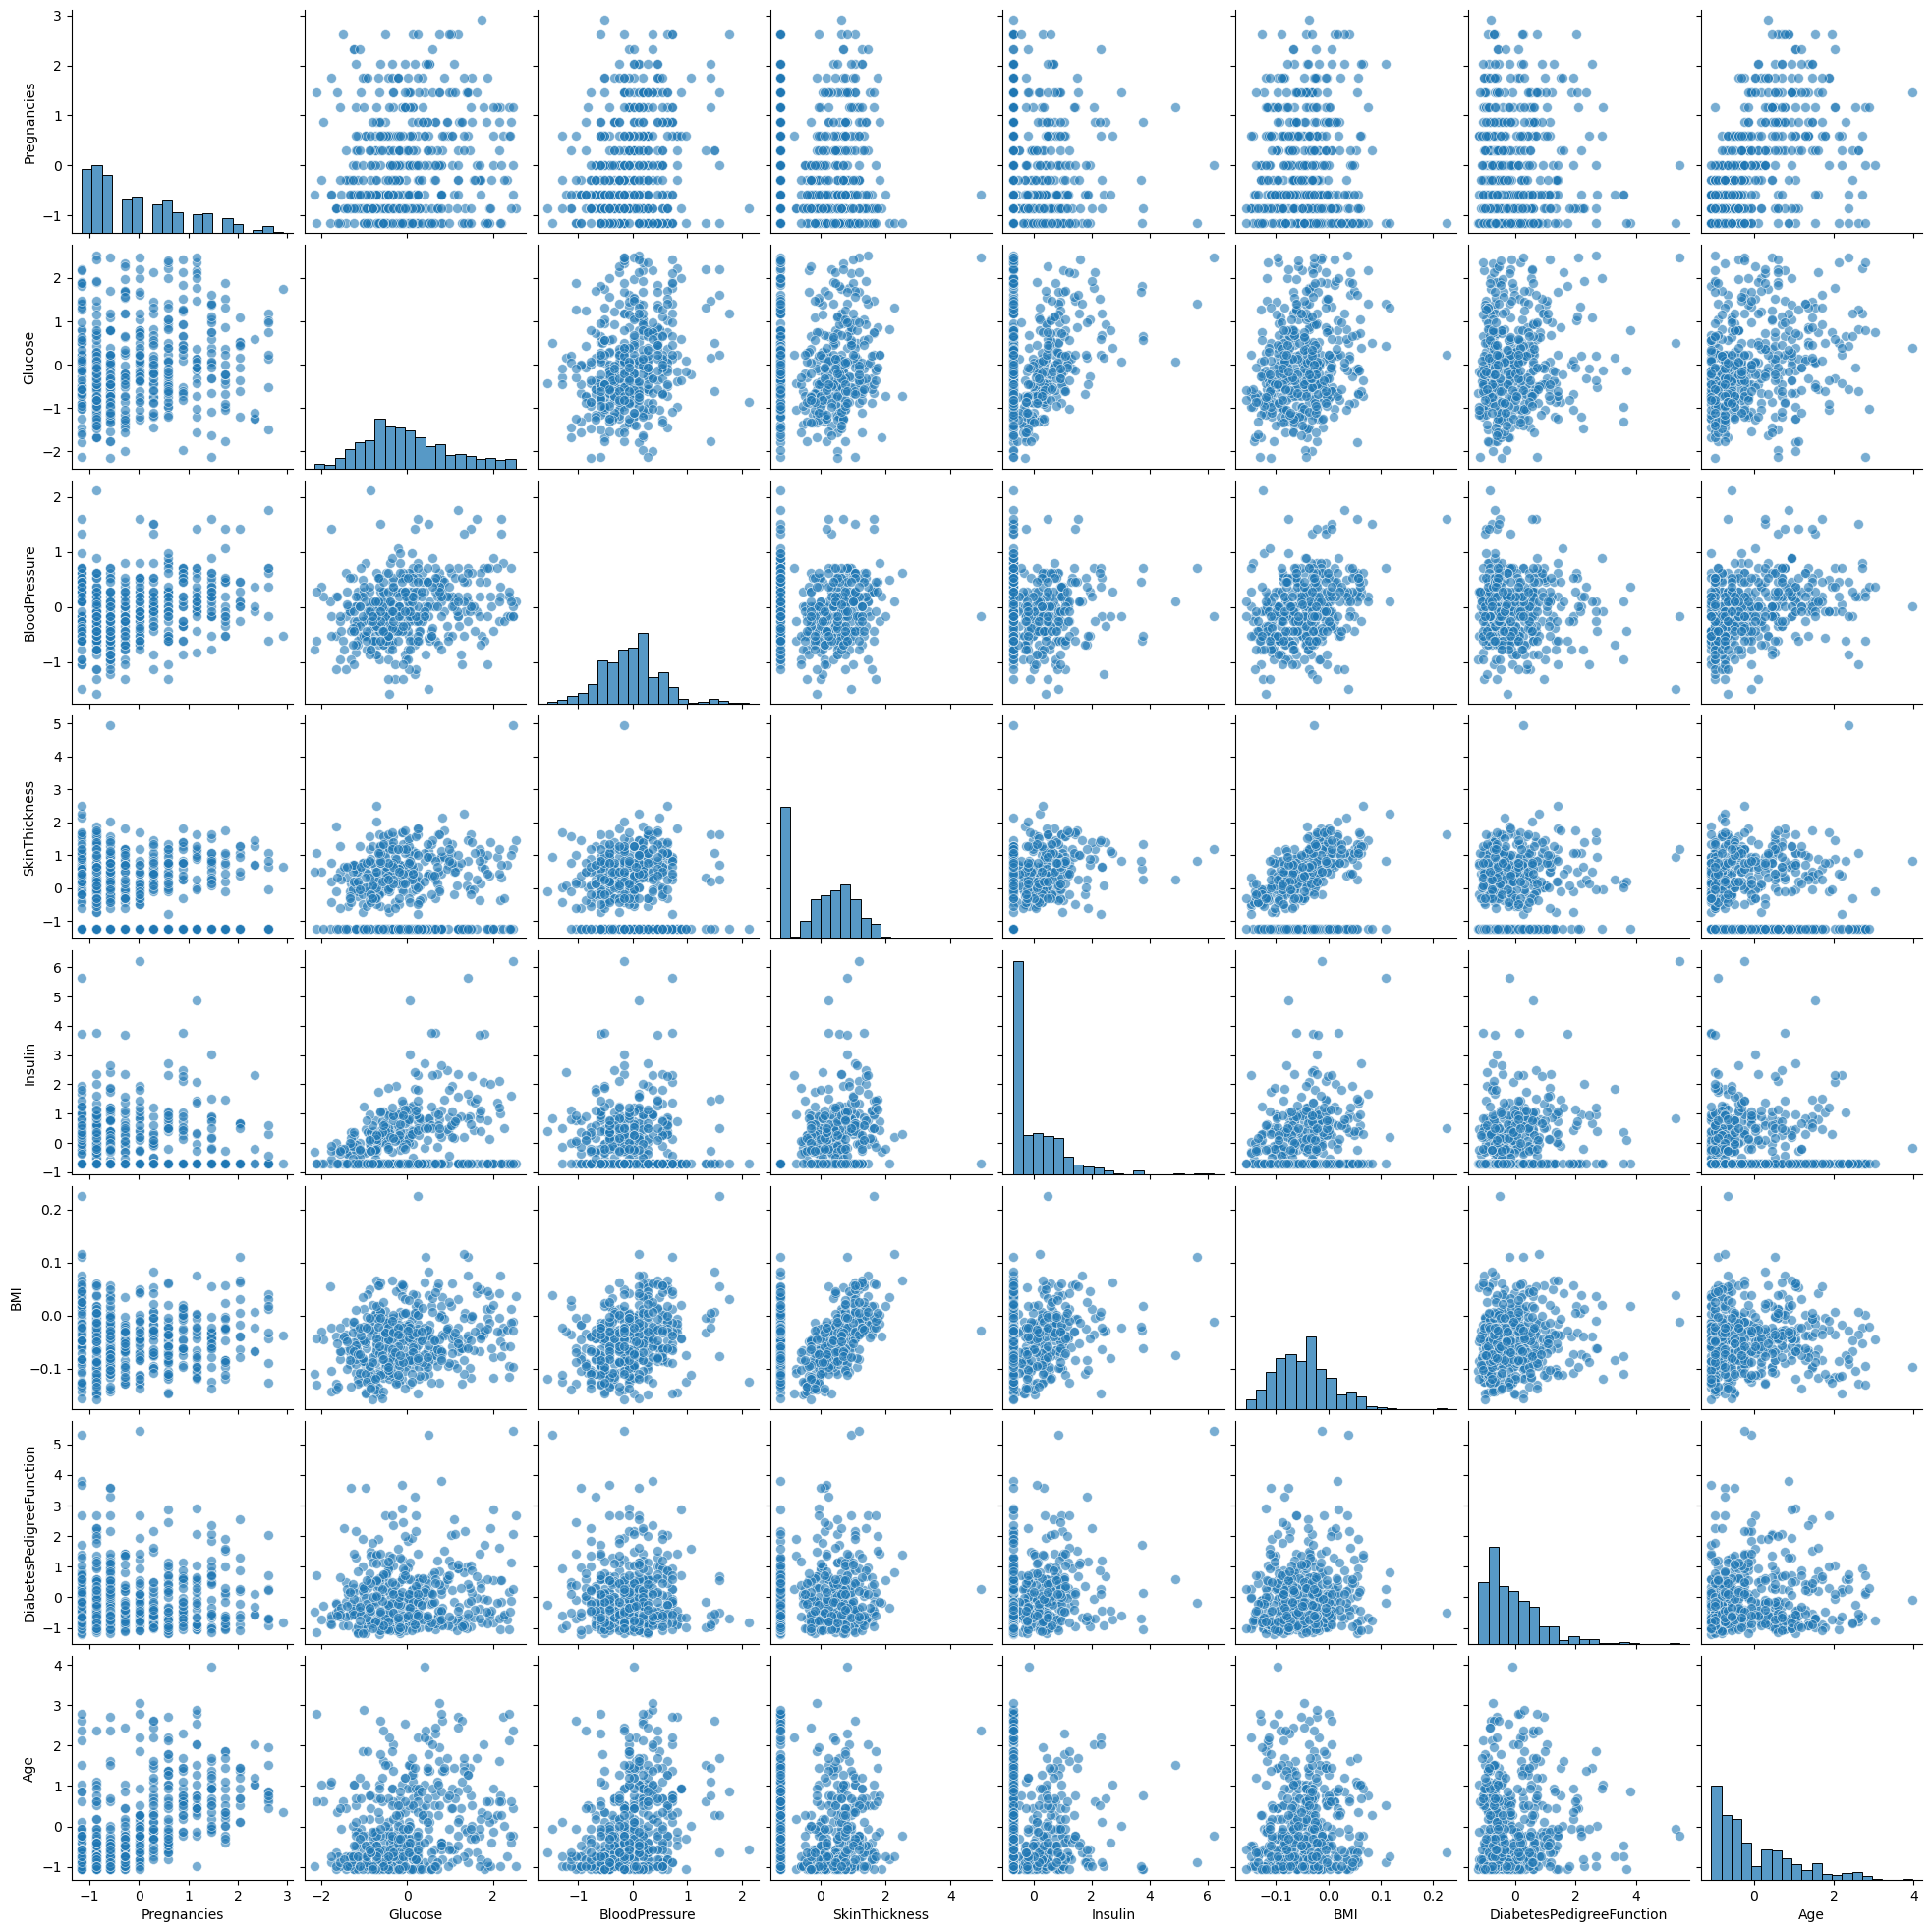

In [25]:
# After removing Outliers' Visualisation
data_no_outlier_visualise = data_no_outlier.copy()
sns.pairplot(data_no_outlier_visualise)
plt.show()

sns.pairplot(data_no_outlier_visualise, 
             diag_kind='hist',
             plot_kws={'alpha': 0.6, 's': 50},
             diag_kws={'bins': 20})
plt.show()


## Imputation Testing

### MICE for Imputation without Outlier

In [26]:
# MICE imputer on standardized data without Outlier
MICE_imputer = IterativeImputer(
    random_state=42,
    max_iter=20,
    tol=1e-4,
    imputation_order='ascending'
)

data_MICE_complete = pd.DataFrame(
    MICE_imputer.fit_transform(data_no_outlier_unscaled),
    columns=data_no_outlier_unscaled.columns,
    index=data_no_outlier_unscaled.index
)

### MICE for Imputation with Outlier

In [27]:
# MICE imputer on standardized data
MICE_imputer = IterativeImputer(
    random_state=42,
    max_iter=20,
    tol=1e-4,
    imputation_order='ascending'
)

data_MICE_outlier_complete = pd.DataFrame(
    MICE_imputer.fit_transform(data_unscaled),
    columns=data_unscaled.columns,
    index=data_unscaled.index
)

### RandomForestRegressor for Imputation without Outlier

In [28]:
# RandomForest imputer on standardized data without Outlier
rf_imputer = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=225,
        random_state=42,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=1,
    ),
    random_state=42,
    max_iter=30,
    tol=1e-3,
    imputation_order='ascending'
)

data_RF_complete = pd.DataFrame(
    rf_imputer.fit_transform(data_no_outlier_unscaled),
    columns=data_no_outlier_unscaled.columns,
    index=data_no_outlier_unscaled.index
)

### RandomForestRegressor for Imputation with Outlier

In [29]:
# RandomForest imputer on standardized data
rf_imputer = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=225,
        random_state=42,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=1,
    ),
    random_state=42,
    max_iter=30,
    tol=1e-3,
    imputation_order='ascending'
)

data_RF_outlier_complete = pd.DataFrame(
    rf_imputer.fit_transform(data_unscaled),
    columns=data_unscaled.columns,
    index=data_unscaled.index
)

### ExtraTreeRegressor for Imputation without Outlier

In [ ]:
# ExtraTree imputer on standardized data without Outlier
et_imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(
        n_estimators=225, 
        random_state=42,
        max_depth=20,
        min_samples_split=5,
    ),
    random_state=42,
    max_iter=45,
    tol=1e-3,
    imputation_order='ascending'
)

data_ET_complete = pd.DataFrame(
    et_imputer.fit_transform(data_no_outlier_unscaled),
    columns=data_no_outlier_unscaled.columns,
    index=data_no_outlier_unscaled.index
)

### ExtraTreeRegressor for Imputation with Outlier

In [ ]:
# ExtraTree imputer on standardized data with Outlier
et_imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(
        n_estimators=225, 
        random_state=42,
        max_depth=20,
        min_samples_split=5,
    ),
    random_state=42,
    max_iter=45,
    tol=1e-3,
    imputation_order='ascending'
)

data_ET_outlier_complete = pd.DataFrame(
    et_imputer.fit_transform(data_unscaled),
    columns=data_unscaled.columns,
    index=data_unscaled.index
)

## Validation

### cross_val_score Validation

In [ ]:
# Define classifier
classifier = RandomForestClassifier(random_state=42)

# Convert to binary
y_train_binary = (y_train > 0.5).astype(int)

# Cross-validation comparison
mice_scores = cross_val_score(classifier, data_MICE_complete, y_train_binary, cv=5, scoring='accuracy')
mice_outlier_scores = cross_val_score(classifier, data_MICE_outlier_complete, y_train_binary, cv=5, scoring='accuracy')
rf_scores = cross_val_score(classifier, data_RF_complete, y_train_binary, cv=5, scoring='accuracy')
rf_outlier_scores = cross_val_score(classifier, data_RF_outlier_complete, y_train_binary, cv=5, scoring='accuracy')
et_scores = cross_val_score(classifier, data_ET_complete, y_train_binary, cv=5, scoring='accuracy')
et_outlier_scores = cross_val_score(classifier, data_ET_outlier_complete, y_train_binary, cv=5, scoring='accuracy')

# Display results
results = {
    'MICE': mice_scores,
    'MICE_Outlier': mice_outlier_scores,
    'RF': rf_scores,
    'RF_Outlier': rf_outlier_scores,
    'ET': et_scores,
    'ET_Outlier': et_outlier_scores
}

# Rank all models by accuracy
ranked_models = sorted(results.items(), key=lambda x: x[1].mean(), reverse=True)

print("\nRanked Models (Best to Worst):")
for i, (name, scores) in enumerate(ranked_models, 1):
    print(f"{i}. {name}: {scores.mean():.4f} ± {scores.std():.4f}")

print(f"\nMost Accurate Model: {ranked_models[0][0]}")
    

### cross_validate Validation

In [ ]:
scoring = ['roc_auc', 'precision', 'recall', 'f1']

mice_results = cross_validate(classifier, data_MICE_complete, y_train_binary, cv=5, scoring=scoring)
mice_outlier_results = cross_validate(classifier, data_MICE_outlier_complete, y_train_binary, cv=5,scoring=scoring)
rf_results = cross_validate(classifier, data_RF_complete, y_train_binary, cv=5, scoring=scoring)
rf_outlier_results = cross_validate(classifier, data_RF_outlier_complete, y_train_binary, cv=5, scoring=scoring)
et_results = cross_validate(classifier, data_ET_complete, y_train_binary, cv=5, scoring=scoring)
et_outlier_results = cross_validate(classifier, data_ET_outlier_complete, y_train_binary, cv=5, scoring=scoring)

for metric in scoring:
    print(f"\n{metric.upper()}:")
    
    # Create results dictionary for this metric
    metric_results = {
        'MICE': mice_results[f'test_{metric}'],
        'MICE_Outlier': mice_outlier_results[f'test_{metric}'],
        'RF': rf_results[f'test_{metric}'],
        'RF_Outlier': rf_outlier_results[f'test_{metric}'],
        'ET': et_results[f'test_{metric}'],
        'ET_Outlier': et_outlier_results[f'test_{metric}']
    }

    # Find the most accurate model for this metric
    best_model = max(metric_results.keys(), key=lambda x: metric_results[x].mean())
    best_score = metric_results[best_model].mean()
    best_std = metric_results[best_model].std()
    
    print(f"\nBest Model for {metric.upper()}: {best_model}")
    print(f"Best Score: {best_score:.4f} ± {best_std:.4f}")
    
    ranked_models = sorted(metric_results.items(), key=lambda x: x[1].mean(), reverse=True)
    print(f"Ranking: {' > '.join([f'{name} ({scores.mean():.4f})' for name, scores in ranked_models])}")

# Secondary Data Visualisation

In [ ]:
# Take RF_Outlier for data visualisation
data_visualised = pd.DataFrame(
    data_MICE_complete,
    columns=data_MICE_complete.columns,
    index=data_MICE_complete.index
)

## Data Description after Cleaning

In [ ]:
data_visualised.describe().T

In [ ]:
data_visualised.info()

In [ ]:
# Verify there is no null
data_visualised.isnull().sum()


In [ ]:
# Verify there is no 0 values for BMI and Blood Pressure
columns_to_check = ['BloodPressure', 'BMI']
zero_counts = data_visualised[columns_to_check].apply(lambda col: (col == 0).sum())
print(zero_counts)

## Outlier removal for better visualisation

In [ ]:
# Remove Outlier from BloodPressure and BMI for better visualisation
data_visualised_scaled = pd.DataFrame(
    scaler.fit_transform(data_visualised), 
    columns=data_visualised.columns, 
    index=data_visualised.index
)

data_visualised_no_outlier = data_visualised_scaled.copy()

data_visualised_no_outlier['BloodPressure'] = np.clip(data_visualised_no_outlier['BloodPressure'], -3, 3)
data_visualised_no_outlier['BMI'] = np.clip(data_visualised_no_outlier['BMI'], -3, 3)

# Remove Standardisation
data_visualised_no_outlier = pd.DataFrame(
    scaler.inverse_transform(data_visualised_no_outlier),
    columns=data_visualised_no_outlier.columns,
    index=data_visualised_no_outlier.index
)

data_visualised_no_outlier.describe().T

## Univariate Analysis

In [ ]:
# Histogram
for column in data_visualised_no_outlier.columns:
    plt.figure(figsize=(8, 6))
    data_visualised_no_outlier[column].hist(edgecolor='black')
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(False)
    plt.tight_layout()
    plt.show()



In [ ]:
# Boxplot
for column in data_visualised_no_outlier.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=data_visualised_no_outlier[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

In [ ]:
# Pie Chart for Outcome
plt.figure(figsize=(8, 6))
y_train.value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#66c2a5', '#fc8d62'])
plt.title('Diabetes Distribution')

## Bivariate Analysis

In [ ]:
# Corelation Matrix
correlation_matrix = data_visualised_no_outlier.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix')

In [ ]:
# Pairplot
pairplot_visualise = pd.concat([data_visualised_no_outlier, y_train], axis=1)
sns.pairplot(pairplot_visualise, hue='Outcome', palette='coolwarm', diag_kind='kde')
plt.suptitle('Pairplot of Diabetes Dataset', y=1.02)

In [ ]:
# Box Plot
plt.figure(figsize=(8, 6))
for column in data_visualised_no_outlier.columns:
    sns.boxplot(x=y_train, y=column, data=data_visualised_no_outlier)
    
    plt.title(f'{column} Distribution by Outcome')
    plt.xlabel('Outcome')
    plt.ylabel({column})

    # Show the plot
    plt.tight_layout()
    plt.show()


In [ ]:
# Create histogram
for column in data_visualised_no_outlier.columns:
    # X feature histogram
    sns.histplot(
        data=data_visualised_no_outlier,
        x=column,
        hue=y_train,
        palette={1: 'red', 0: 'blue'},
        alpha=0.7,
        kde=True,
    )
    
    plt.suptitle(f'Feature Distributions: {column} & {y_train.name}')
    plt.tight_layout()
    plt.show()


## Multivariate Analysis

In [ ]:
# Parallel Coordinate Plot
plt.figure(figsize=(10, 6))
parallel_coordinates(pairplot_visualise, 'Outcome', color=['blue', 'red'])
plt.title('Parallel Coordinates Plot of Diabetes')
plt.xlabel('Features')
plt.ylabel('Values')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# PCA-Based Visualisation
import itertools

# List of the 8 features
features = data_visualised_no_outlier.columns

# Generate all unique pairs of features
feature_pairs = list(itertools.combinations(features, 2))

# Create scatter plots for each pair
for x_feature, y_feature in feature_pairs:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=data_visualised_no_outlier,
        x=x_feature,
        y=y_feature,
        hue=y_train,
        palette={1: 'red', 0: 'blue'}
    )
    plt.title(f'Scatter Plot: {x_feature} vs {y_feature}')
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Feature Reduction

## Complete Data Imputation

In [ ]:
# Using RF with outliers to impute data for X_train, X_val, X_test
train_imputed_arrays = []
val_imputed_arrays = []
test_imputed_arrays = []

# Remove unlogical data from BMI, as the max of BMI is 100 
X_train.loc[X_train['BMI'] > 100, 'BMI'] = np.nan
X_val.loc[X_val['BMI'] > 100, 'BMI'] = np.nan
X_test.loc[X_test['BMI'] > 100, 'BMI'] = np.nan

np.random.seed(42)  # For reproducibility of seed generation
random_seeds = np.random.randint(0, 10000, 5)

for i, seed in enumerate(random_seeds):
    mice_imputer = IterativeImputer(
        random_state=seed,
        max_iter=20,
        tol=1e-4,
        imputation_order='ascending'
    )

    # Fit on training data only
    mice_imputer.fit(X_train)

    # Transform all sets
    X_train_imputed = mice_imputer.transform(X_train)
    X_val_imputed = mice_imputer.transform(X_val)
    X_test_imputed = mice_imputer.transform(X_test)

    # Store arrays
    train_imputed_arrays.append(X_train_imputed)
    val_imputed_arrays.append(X_val_imputed)
    test_imputed_arrays.append(X_test_imputed)

# Average results
X_train_avg = np.mean(train_imputed_arrays, axis=0)
X_val_avg = np.mean(val_imputed_arrays, axis=0)
X_test_avg = np.mean(test_imputed_arrays, axis=0)

# Convert to DataFrames
X_train = pd.DataFrame(X_train_avg, columns=X_train.columns, index=X_train.index)
X_val = pd.DataFrame(X_val_avg, columns=X_val.columns, index=X_val.index)
X_test = pd.DataFrame(X_test_avg, columns=X_test.columns, index=X_test.index)

## Skewedness

In [ ]:
# Check for skewedness
for column in X_train.columns:
    skewness = X_train[column].skew()
    print(f"Skewness for {column}: {skewness}")

In [ ]:
# Dealing with Skewedness
X_train_transformed = X_train.copy()
X_val_transformed = X_val.copy()
X_test_transformed = X_test.copy()

# Severe skewness 
severely_skewed = ['BloodPressure', 'Insulin']
for feature in severely_skewed:
    if feature in X_train.columns:
        # Add 1 to handle zeros, then log transform
        X_train_transformed[feature] = np.log1p(X_train[feature])
        X_val_transformed[feature] = np.log1p(X_val[feature])
        X_test_transformed[feature] = np.log1p(X_test[feature])

# Moderate skewness
moderately_skewed = ['DiabetesPedigreeFunction', 'Age']
for feature in moderately_skewed:
    if feature in X_train.columns:
        X_train_transformed[feature] = np.sqrt(X_train[feature])
        X_val_transformed[feature] = np.sqrt(X_val[feature])
        X_test_transformed[feature] = np.sqrt(X_test[feature])

## Class Imbalance

In [ ]:
# Check for class imbalance
class_percentages = y_train.value_counts(normalize=True) * 100
print("\nClass distribution (percentages):")
print(class_percentages)

## Feature Importance

### Random Forest

In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

importances = rf_model.feature_importances_
feature_names = X_train.columns

rf_df = pd.DataFrame({
    'Feature': feature_names,
    'TreeImportance': importances
}).sort_values(by='TreeImportance', ascending=False)

print(rf_df)

plt.figure(figsize=(10, 6))
plt.barh(rf_df['Feature'], rf_df['TreeImportance'])
plt.gca().invert_yaxis()
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.show()

### Logistic Regression 

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter= 1000
)
model.fit(X_train_transformed, y_train)

coefficients = model.coef_[0]
lr_df = pd.DataFrame({
    'Feature': X_train.columns,
    'LogisticImportance': abs(coefficients)
}).sort_values(by='LogisticImportance', ascending=False)

print(lr_df)

plt.figure(figsize=(10, 6))
plt.barh(lr_df['Feature'], lr_df['LogisticImportance'])
plt.gca().invert_yaxis()
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.show()

### Permutation Importance

In [ ]:
result = permutation_importance(rf_model, X_train, y_train, n_repeats=10, random_state=42)

perm_df = pd.DataFrame({
    'Feature': X_train.columns,
    'PermImportance': result.importances_mean
}).sort_values(by='PermImportance', ascending=False)

print(perm_df)

plt.figure(figsize=(10, 6))
plt.barh(perm_df['Feature'], perm_df['PermImportance'])
plt.gca().invert_yaxis()
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.show()

### Feature Importance Ranking

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Merge all three importance scores
merged_df = perm_df.merge(lr_df, on='Feature').merge(rf_df, on='Feature')

scaler = MinMaxScaler()

# Only scale the importance columns
importance_values = merged_df[['PermImportance', 'LogisticImportance', 'TreeImportance']]
scaled_values = scaler.fit_transform(importance_values)

# Replace in DataFrame
merged_df[['PermImportance', 'LogisticImportance', 'TreeImportance']] = scaled_values

merged_df['MeanImportance'] = merged_df[[
    'PermImportance', 'LogisticImportance', 'TreeImportance'
]].mean(axis=1)

merged_df = merged_df.sort_values(by='MeanImportance', ascending=False)

print(merged_df)

top_feature = merged_df.iloc[0]['Feature']
print(f"\nMost consistently important feature: {top_feature}")

merged_df.set_index('Feature')[[
    'PermImportance', 'LogisticImportance', 'TreeImportance'
]].plot(kind='bar', figsize=(12, 6))

plt.title("Feature Importance Comparison")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()



# Extracting data

In [ ]:
# Combine X and Y into respective dataframes
train_combined = pd.concat([X_train, y_train], axis=1)
val_combined = pd.concat([X_val, y_val], axis=1)
test_combined = pd.concat([X_test, y_test], axis=1)

train_transformed_combined = pd.concat([X_train_transformed, y_train], axis=1)
val_transformed_combined = pd.concat([X_val, y_val], axis=1)
test_transformed_combined = pd.concat([X_test, y_test], axis=1)

# Save each dataframe to specific sheet in Excel
with pd.ExcelWriter('DiabetesCleaned.xlsx', engine='openpyxl') as writer:
    train_combined.to_excel(writer, sheet_name='Train Data', index=False)
    train_transformed_combined.to_excel(writer, sheet_name='Train Transformed Data', index=False)
    val_combined.to_excel(writer, sheet_name='Validate Data', index=False)
    val_transformed_combined.to_excel(writer, sheet_name='Validate Transformed Data', index=False)
    test_combined.to_excel(writer, sheet_name='Test Data', index=False)
    test_transformed_combined.to_excel(writer, sheet_name='Test Transformed Data', index=False)